# Komparativna analiza regresionih modela mašinskog učenja za procenu oglašenih cena stambenih nekretnina u Beogradu

## Istraživačko pitanje

> **Koji regresioni algoritam mašinskog učenja najbolje procenjuje oglašene
> cene stambenih nekretnina u Beogradu na osnovu karakteristika navedenih u
> oglasima?**

Podaci potiču iz oglasa za prodaju nekretnina, pa je i ciljna promenljiva
**oglašena cena** - cena koju prodavac/agencija traži u oglasu, a ne
tržišna ili realizovana (transakciona) cena. Cilj ovog rada nije da unapred
favorizuje bilo koji model, već da se **eksperimentalno, na fer i
reproduktivan način** utvrdi koji od nekoliko standardnih regresionih
algoritama mašinskog učenja najbolje procenjuje oglašenu cenu stambene
nekretnine na osnovu karakteristika iz oglasa (površina, broj soba, sprat,
lokacija, tip nekretnine, navedene pogodnosti...).

## Modeli koji se porede

| Model | Tip | Zašto je uključen |
|---|---|---|
| Linear Regression | Linearni | Najjednostavniji mogući baseline - donja granica očekivanog učinka |
| Decision Tree | Stablo odlučivanja | Jednostavan nelinearni model, osnova za ansamble |
| Random Forest | Ansambl stabala (bagging) | Standardni snažan baseline za tabelarne podatke |
| XGBoost | Gradient boosting | Industrijski standard za tabelarne podatke u takmičenjima i praksi |
| CatBoost | Gradient boosting | Nativna podrška kategorijskih atributa, manja potreba za preprocessing-om |
| LightGBM | Gradient boosting (histogram-based) | Veoma brz trening, mala potrošnja memorije |
| MLP (neuronska mreža) | Duboko učenje | Fleksibilan univerzalni aproksimator, tema veštačke inteligencije |

## Protokol poređenja (fer i reproduktivno)

Da bi poređenje bilo validno, **svi modeli koriste**:
- isti skup ulaznih karakteristika i isti pipeline za pripremu podataka
  (imputacija + StandardScaler + OneHotEncoder unutar `ColumnTransformer`),
- istu podelu na train/test (`random_state` fiksiran), izvršenu **pre**
  bilo kakve imputacije, skaliranja ili kodiranja,
- istu 5-struku unakrsnu validaciju (K-Fold, isti splitovi za sve modele)
  u kojoj se ceo pipeline ponovo fituje u svakom fold-u samo na trening
  delu podataka,
- istu ciljnu promenljivu - `log1p(oglašena cena)` pri treniranju, sa
  vraćanjem u evre (`expm1`) pri evaluaciji,
- iste metrike: MAE, RMSE, MAPE, R² (na EUR skali, na test skupu koji
  nijedan model nije video tokom treniranja/tuning-a).

## Struktura notebook-a

1. Uvod
2. Učitavanje podataka
3. Istraživačka analiza podataka (EDA) - na sirovim podacima
4. Čišćenje podataka
5. Feature Engineering
6. Log transformacija ciljne promenljive
7. Preprocessing Pipeline
8. Train/Test Split
9. Cross Validation - protokol
10. Linear Regression
11. Decision Tree
12. Random Forest (+ tuning)
13. XGBoost (+ tuning)
14. CatBoost (+ tuning)
15. LightGBM (+ tuning)
16. MLP neuronska mreža (+ arhitektura)
17. Pregled hiperparametarskog podešavanja
18. Evaluacija i poređenje modela
19. Vizuelno poređenje modela
20. Poređenje rezultata unakrsne validacije i nezavisnog test skupa
21. Residual analiza
22. Feature Importance
23. SHAP analiza
24. Diskusija rezultata
25. Završni zaključak


## 2. Učitavanje podataka

In [1]:
import os
import json
import time
import pickle
import warnings

# TensorFlow ispisuje dosta INFO/WARNING poruka o oneDNN optimizacijama i
# dostupnim CPU instrukcijama pri uvozu - bezopasne su, ali zatrpavaju izlaz,
# pa ih utišavamo PRE uvoza tensorflow-a.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

CSV_PATH = "../data/nekretnine_listings.csv"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

BELGRADE_CENTER_LAT = 44.8125
BELGRADE_CENTER_LON = 20.4612

print("Biblioteke uspešno učitane.")
print("TensorFlow verzija:", tf.__version__)


Biblioteke uspešno učitane.
TensorFlow verzija: 2.21.0


In [2]:
df_raw = pd.read_csv(CSV_PATH)
print(f"Sirovi skup podataka: {df_raw.shape[0]} redova, {df_raw.shape[1]} kolona")
df_raw.head()

Sirovi skup podataka: 1915 redova, 30 kolona


,listing_id,url,title,contract,is_new,price_eur,price_raw,price_visible,typology,category,...,heating,municipality,neighborhood,city,address,latitude,longitude,agency,description,source_file
0,41749,https://www.nekretnine.rs/oglasi/41749/,"Četvorosobni stan Ulica Danijelova 10, Dušanov...",sale,False,615000.0,€ 615.00,True,Četvorosobni stan,Stambene nekretnine,...,Autonomo,Voždovac,Dušanovac,Beograd,Ulica Danijelova,44.784199,20.477200,UNITED CITY GROUP,* ALTERRA VERSA - SMART HOME! * 153 m2 + 115 m...,beograd_page_001.html
1,41747,https://www.nekretnine.rs/oglasi/41747/,"Četvorosobni stan Ulica Danijelova 10, Dušanov...",sale,False,257000.0,€ 257.00,True,Četvorosobni stan,Stambene nekretnine,...,Autonomo,Voždovac,Dušanovac,Beograd,Ulica Danijelova,44.784199,20.477200,UNITED CITY GROUP,U „Alterra Versa“ objektu ne kupujete samo kva...,beograd_page_001.html
2,77431,https://www.nekretnine.rs/oglasi/77431/,"Četvorosobni stan Bulevar Mihajla Pupina, Akad...",sale,False,750000.0,€ 750.00,True,Četvorosobni stan,Stambene nekretnine,...,Centralizzato,Novi Beograd,Akademija - Arena,Beograd,Bulevar Mihajla Pupina,44.821098,20.420099,BEOSTATUS,"Na Novom Beogradu, Bul Mihajla Pupina u čuveno...",beograd_page_001.html
3,1015817,https://www.nekretnine.rs/oglasi/1015817/,"Dvosobni stan Ulica Omladinskih brigada, Belvi...",sale,False,261250.0,€ 261.25,True,Dvosobni stan,Stambene nekretnine,...,Centralizzato,Novi Beograd,Belvil,Beograd,Ulica Omladinskih brigada,44.812698,20.402800,DANOS AND ASSOCIATES,"Soul 64 Novo, 2.0 na veoma traženoj lokaciji b...",beograd_page_001.html
4,1210527,https://www.nekretnine.rs/oglasi/1210527/,"Zgrada Ulica Ustanicka 92, Šumice, Beograd",sale,False,229482.0,€ 229.48,True,Zgrada,Zgrade - Građevine,...,Assente,Voždovac,Šumice,Beograd,Ulica Ustanicka,44.784401,20.484400,arcoSITE d.o.o.,"U srcu Voždovca, na atraktivnoj lokaciji, nudi...",beograd_page_001.html


## 3. Istraživačka analiza podataka (EDA)

Analiza u ovom odeljku se radi na **sirovim, još neočišćenim** podacima -
cilj je razumeti podatke pre bilo kakve intervencije (čišćenja), i na
osnovu ove analize doneti informisane odluke o čišćenju u odeljku 4
(npr. koje granice koristiti za filtriranje outliera).

### 3.1 Dimenzije, tipovi podataka i osnovni pregled

In [3]:
print(f"Dimenzije: {df_raw.shape[0]} redova x {df_raw.shape[1]} kolona")
print()
dtype_table = pd.DataFrame({
    "Tip podatka": df_raw.dtypes.astype(str),
    "Broj jedinstvenih vrednosti": df_raw.nunique(),
})
dtype_table

Dimenzije: 1915 redova x 30 kolona



,Tip podatka,Broj jedinstvenih vrednosti
listing_id,int64,1915
url,str,1915
title,str,1559
contract,str,1
is_new,bool,2
price_eur,float64,701
price_raw,str,696
price_visible,bool,2
typology,str,16
category,str,3


### 3.2 Nedostajuće vrednosti

In [4]:
missing_table = pd.DataFrame({
    "Broj NaN": df_raw.isna().sum(),
    "Procenat NaN (%)": (df_raw.isna().sum() / len(df_raw) * 100).round(2),
})
missing_table = missing_table[missing_table["Broj NaN"] > 0].sort_values("Broj NaN", ascending=False)
missing_table

,Broj NaN,Procenat NaN (%)
description,1904,99.43
furnished,1731,90.39
balcony,1606,83.86
basement,1473,76.92
elevator,730,38.12
terrace,565,29.50
bedrooms,473,24.70
bathrooms,457,23.86
floor,309,16.14
address,197,10.29


### 3.3 Duplikati i ponovljeni oglasi

Pored formalnih duplikata po `listing_id`, proveravamo i **potencijalno
ponovljene oglase iste nekretnine**: različit `listing_id`, ali identična
lokacija (koordinate), površina i oglašena cena - tipičan znak da je ista
nekretnina oglašena više puta (ponovljeni inserat ili isto preko više
agencija). Proveravamo i kombinaciju adrese sa površinom i cenom. Takve
grupe se ovde samo detektuju i prikazuju - **ne brišu se automatski**,
jer slični redovi mogu predstavljati i različite stanove u istoj zgradi;
odluka o uklanjanju donosi se u odeljku 4, nakon provere sadržaja primera.


In [5]:
n_duplicates = df_raw.duplicated(subset=["listing_id"]).sum()
print(f"Broj duplikata po listing_id: {n_duplicates}")
n_duplicates_full = df_raw.duplicated().sum()
print(f"Broj potpuno identičnih redova (sve kolone): {n_duplicates_full}")

# Potencijalno ponovljeni oglasi iste nekretnine:
# identicne koordinate + povrsina + oglašena cena, a različit listing_id.
key_cols = ["latitude", "longitude", "area_sqm", "price_eur"]
mask_repeat = df_raw[key_cols].notna().all(axis=1) & df_raw.duplicated(subset=key_cols, keep=False)
print(f"\nRedova u grupama sa identičnim koordinatama, površinom i cenom: "
      f"{mask_repeat.sum()} ({df_raw[mask_repeat].groupby(key_cols).ngroups} grupa)")

# Alternativna provera: adresa + povrsina + cena
addr_cols = ["address", "area_sqm", "price_eur"]
mask_addr = df_raw[addr_cols].notna().all(axis=1) & df_raw.duplicated(subset=addr_cols, keep=False)
print(f"Redova u grupama sa identičnom adresom, površinom i cenom: "
      f"{mask_addr.sum()} ({df_raw[mask_addr].groupby(addr_cols).ngroups} grupa)")

# Primer najvece grupe - proveravamo da li je ista nekretnina oglašena
# više puta (isti naslov/agencija/cena) ili su to različiti objekti
grp = df_raw[mask_repeat].groupby(key_cols)
najveca_grupa = grp.size().idxmax()
primer = grp.get_group(najveca_grupa)
print(f"\nPrimer najveće grupe ({len(primer)} oglasa, identične koordinate/površina/cena):")
primer[["listing_id", "title", "typology", "area_sqm", "price_eur", "agency"]]


Broj duplikata po listing_id: 0
Broj potpuno identičnih redova (sve kolone): 0

Redova u grupama sa identičnim koordinatama, površinom i cenom: 153 (63 grupa)
Redova u grupama sa identičnom adresom, površinom i cenom: 228 (87 grupa)

Primer najveće grupe (6 oglasa, identične koordinate/površina/cena):


,listing_id,title,typology,area_sqm,price_eur,agency
406,1215773,"Trosobni stan Ulica Zivka Davidovica, Kluz - Z...",Trosobni stan,56.0,180000.0,TREZOR NEKRETNINE
469,1268767,"Trosobni stan Ulica Zivka Davidovica, Kluz - Z...",Trosobni stan,56.0,180000.0,KEY REAL ESTATE
492,1247067,"Trosobni stan Ulica Zivka Davidovica, Kluz - Z...",Trosobni stan,56.0,180000.0,KEY REAL ESTATE
515,1191819,"Trosobni stan Ulica Zivka Davidovica, Kluz - Z...",Trosobni stan,56.0,180000.0,KEY REAL ESTATE
520,1197185,"Trosobni stan Ulica Zivka Davidovica, Kluz - Z...",Trosobni stan,56.0,180000.0,KEY REAL ESTATE
1458,1309225,"Trosobni stan Ulica Zivka Davidovica, Kluz - Z...",Trosobni stan,56.0,180000.0,KEY REAL ESTATE


### 3.4 Opisna statistika numeričkih atributa

In [6]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
listing_id,1915.0,796856.947781,501324.303823,53.000000,95670.000000,1.032245e+06,1.191882e+06,1.342373e+06
price_eur,1885.0,349448.728912,294190.478720,113.000000,169800.000000,2.680000e+05,4.000000e+05,3.450000e+06
area_sqm,1912.0,107.148492,89.977402,1.000000,57.000000,8.050000e+01,1.210000e+02,9.730000e+02
bedrooms,1442.0,2.938280,1.469917,0.000000,2.000000,3.000000e+00,4.000000e+00,1.200000e+01
latitude,1872.0,44.784921,0.060870,44.349998,44.780015,4.479806e+01,4.481192e+01,4.506794e+01
longitude,1872.0,20.454095,0.070380,20.136370,20.417999,2.046400e+01,2.048580e+01,2.075810e+01


### 3.5 Distribucija ciljne promenljive (cena) i log(cena)

Cena je izrazito desno zakošena - mali broj veoma skupih nekretnina
"izdužuje" rep raspodele. Log-transformacija (`log1p`) čini raspodelu
znatno simetričnijom i bližom normalnoj, što će biti bitno pri treniranju
modela (odeljak 6).

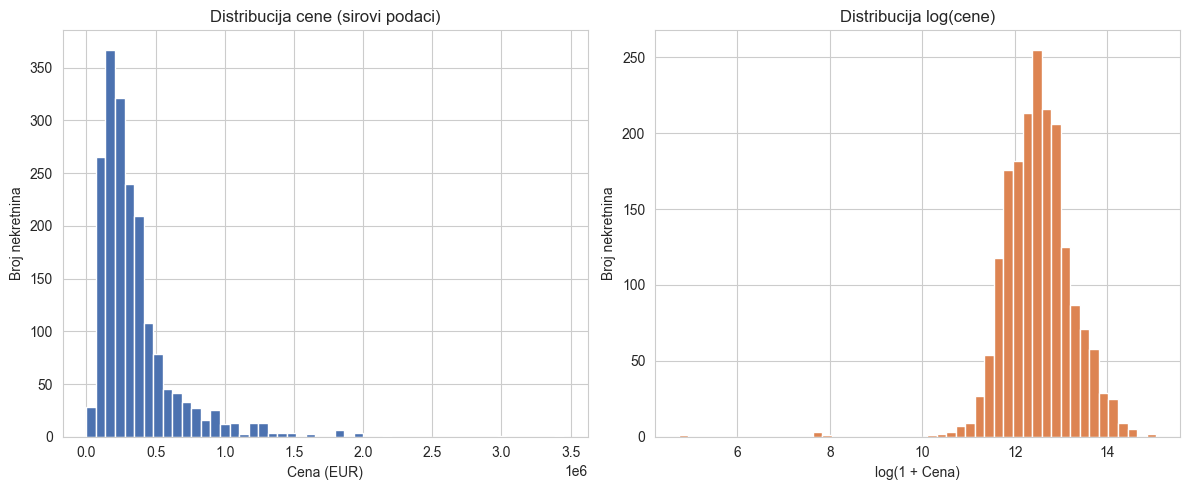

count    1.885000e+03
mean     3.494487e+05
std      2.941905e+05
min      1.130000e+02
25%      1.698000e+05
50%      2.680000e+05
75%      4.000000e+05
max      3.450000e+06
Name: price_eur, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_raw["price_eur"].dropna(), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Cena (EUR)")
axes[0].set_ylabel("Broj nekretnina")
axes[0].set_title("Distribucija cene (sirovi podaci)")

axes[1].hist(np.log1p(df_raw["price_eur"].dropna()), bins=50, color="#DD8452", edgecolor="white")
axes[1].set_xlabel("log(1 + Cena)")
axes[1].set_ylabel("Broj nekretnina")
axes[1].set_title("Distribucija log(cene)")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_price_distribution.png"), dpi=150)
plt.show()

print(df_raw["price_eur"].describe())

### 3.6 Korelaciona matrica numeričkih atributa

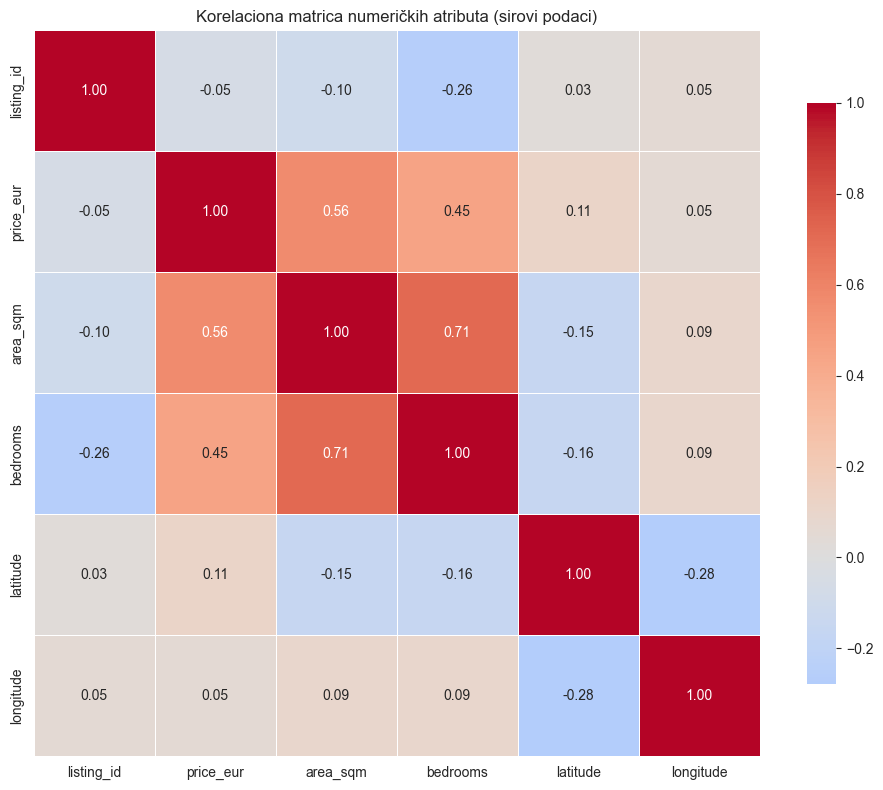

In [8]:
numeric_cols_raw = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix_raw = df_raw[numeric_cols_raw].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_raw, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Korelaciona matrica numeričkih atributa (sirovi podaci)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_correlation_matrix.png"), dpi=150)
plt.show()

In [9]:
corr_with_price = corr_matrix_raw["price_eur"].drop("price_eur").sort_values(ascending=False)
print("Korelacija numeričkih atributa sa cenom (price_eur):")
corr_with_price

Korelacija numeričkih atributa sa cenom (price_eur):


area_sqm      0.561551
bedrooms      0.450925
latitude      0.113534
longitude     0.051013
listing_id   -0.053880
Name: price_eur, dtype: float64

### 3.7 Histogrami svih numeričkih atributa

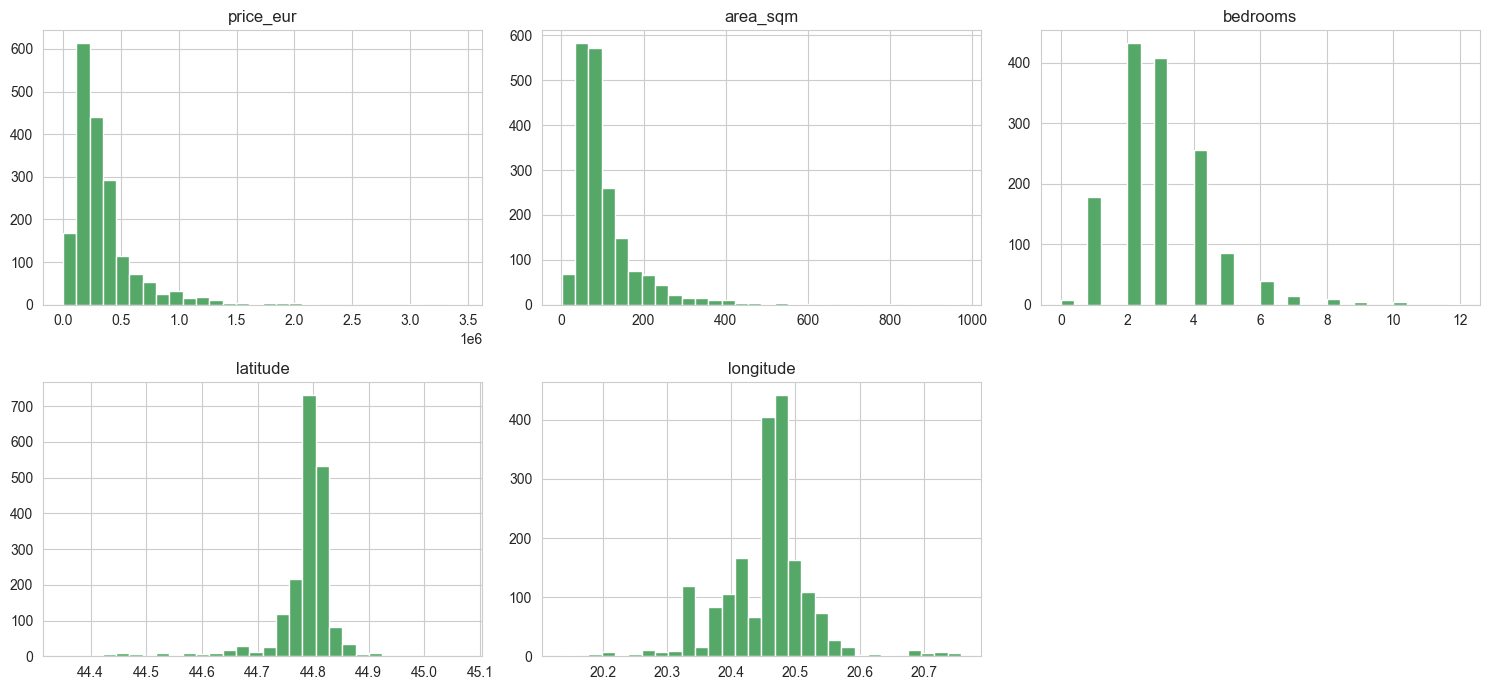

In [10]:
num_cols_for_hist = [c for c in numeric_cols_raw if c not in ("listing_id",)]
n_cols = 3
n_rows = int(np.ceil(len(num_cols_for_hist) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols_for_hist):
    axes[i].hist(df_raw[col].dropna(), bins=30, color="#55A868", edgecolor="white")
    axes[i].set_title(col)
for j in range(len(num_cols_for_hist), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_all_histograms.png"), dpi=150)
plt.show()

### 3.8 Boxplot analiza (otkrivanje outliera)

Boxplotovi ispod prikazuju cenu i površinu u sirovom obliku. Vidljiv je
mali broj ekstremnih vrednosti - ovo direktno informiše granice
filtriranja koje se koriste u odeljku 4 (čišćenje podataka).

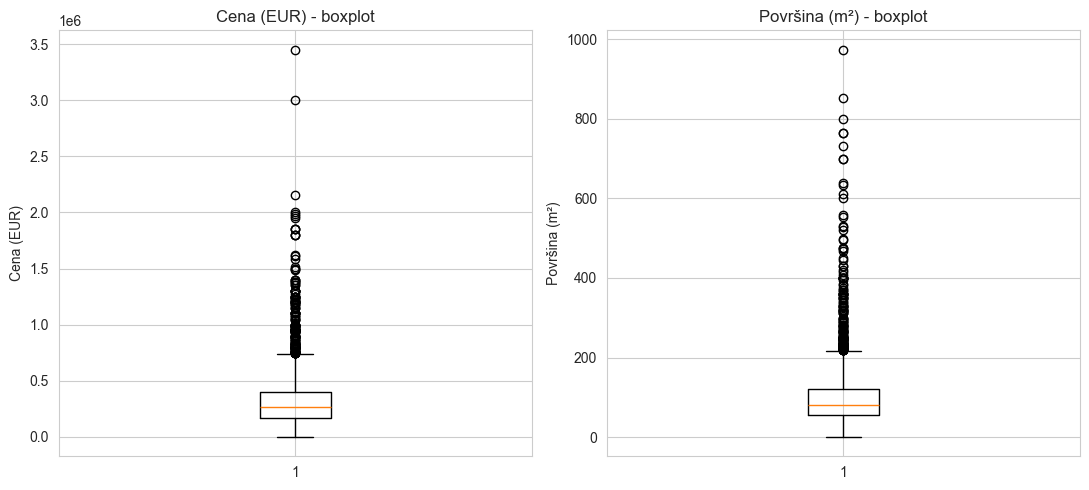

Cena - IQR granice (Q1-1.5*IQR, Q3+1.5*IQR): [-175,500, 745,300] EUR
Broj vrednosti iznad gornje IQR granice: 162


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].boxplot(df_raw["price_eur"].dropna(), vert=True)
axes[0].set_title("Cena (EUR) - boxplot")
axes[0].set_ylabel("Cena (EUR)")

axes[1].boxplot(df_raw["area_sqm"].dropna(), vert=True)
axes[1].set_title("Površina (m²) - boxplot")
axes[1].set_ylabel("Površina (m²)")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_boxplots_outliers.png"), dpi=150)
plt.show()

q1, q3 = df_raw["price_eur"].quantile([0.25, 0.75])
iqr = q3 - q1
print(f"Cena - IQR granice (Q1-1.5*IQR, Q3+1.5*IQR): "
      f"[{q1 - 1.5*iqr:,.0f}, {q3 + 1.5*iqr:,.0f}] EUR")
print(f"Broj vrednosti iznad gornje IQR granice: "
      f"{(df_raw['price_eur'] > q3 + 1.5*iqr).sum()}")

### 3.9 Cena u odnosu na najvažnije numeričke karakteristike (scatter)

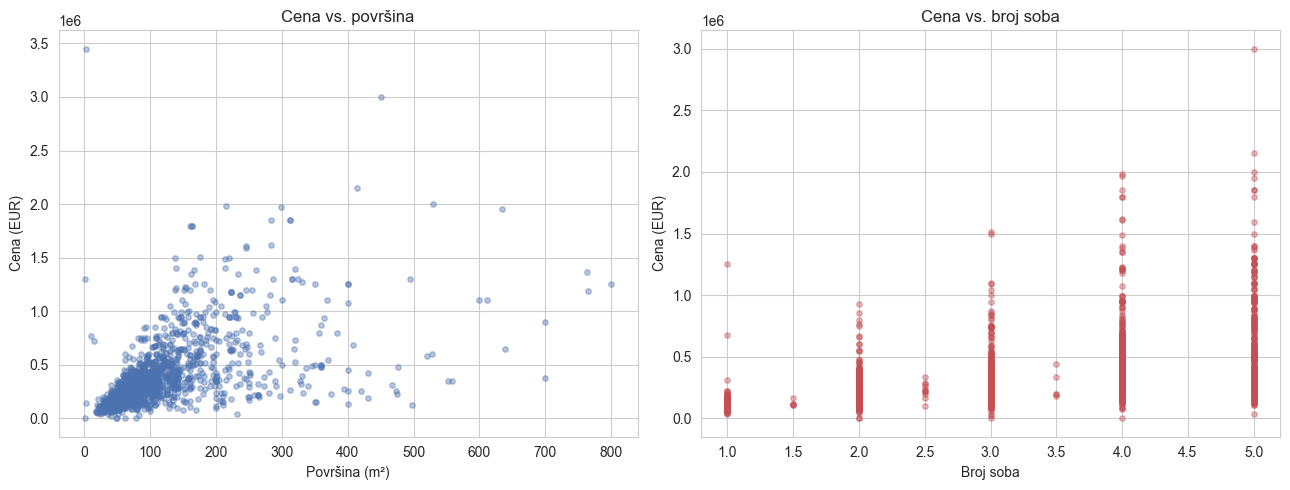

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_raw["area_sqm"], df_raw["price_eur"], alpha=0.4, s=15, color="#4C72B0")
axes[0].set_xlabel("Površina (m²)")
axes[0].set_ylabel("Cena (EUR)")
axes[0].set_title("Cena vs. površina")

axes[1].scatter(df_raw["rooms"].apply(lambda v: pd.to_numeric(str(v).replace("+", ""), errors="coerce")),
                df_raw["price_eur"], alpha=0.4, s=15, color="#C44E52")
axes[1].set_xlabel("Broj soba")
axes[1].set_ylabel("Cena (EUR)")
axes[1].set_title("Cena vs. broj soba")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_scatter_price_vs_features.png"), dpi=150)
plt.show()

### 3.10 Analiza kategorijskih atributa

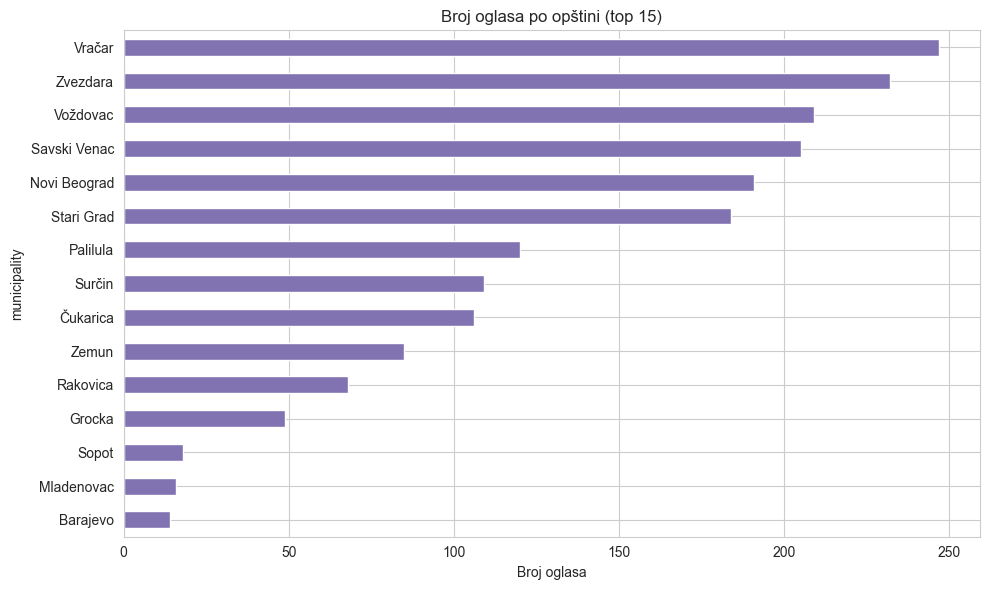

Broj jedinstvenih opština (municipality): 17
Broj jedinstvenih naselja (neighborhood): 127
Broj jedinstvenih tipova grejanja (heating): 3


In [13]:
top_municipalities = df_raw["municipality"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_municipalities.sort_values().plot(kind="barh", color="#8172B2")
plt.xlabel("Broj oglasa")
plt.title("Broj oglasa po opštini (top 15)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_municipality_counts.png"), dpi=150)
plt.show()

print(f"Broj jedinstvenih opština (municipality): {df_raw['municipality'].nunique()}")
print(f"Broj jedinstvenih naselja (neighborhood): {df_raw['neighborhood'].nunique()}")
print(f"Broj jedinstvenih tipova grejanja (heating): {df_raw['heating'].nunique()}")

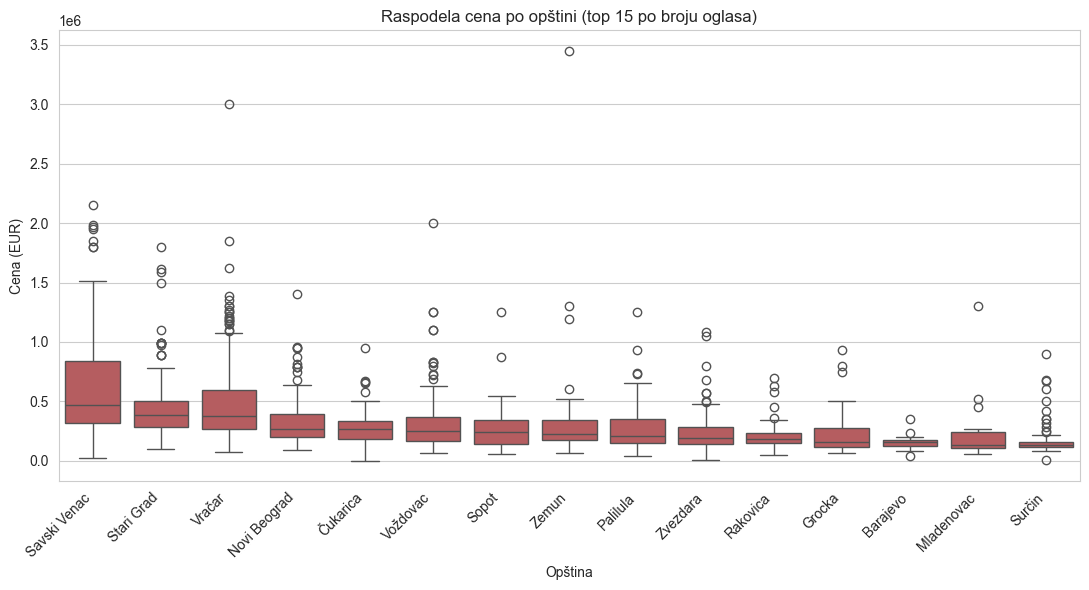

In [14]:
top_mun_15 = df_raw["municipality"].value_counts().head(15).index
df_top_mun_raw = df_raw[df_raw["municipality"].isin(top_mun_15)]

order = df_top_mun_raw.groupby("municipality")["price_eur"].median().sort_values(ascending=False).index

plt.figure(figsize=(11, 6))
sns.boxplot(data=df_top_mun_raw, x="municipality", y="price_eur", order=order, color="#C44E52")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Opština")
plt.ylabel("Cena (EUR)")
plt.title("Raspodela cena po opštini (top 15 po broju oglasa)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_price_by_municipality.png"), dpi=150)
plt.show()

### 3.11 Zaključci EDA

- **Cena** je izrazito desno zakošena (skew), sa dugim repom ka visokim
  vrednostima - opravdava upotrebu log-transformacije pri modelovanju.
- **Površina** ima najjaču pozitivnu korelaciju sa cenom od svih sirovih
  numeričkih atributa - očekivano, veći stan je po pravilu skuplji.
- Postoji mali broj **outliera** i u ceni i u površini (npr. cena blizu
  0 verovatno je greška unosa, dok ekstremno velike površine odgovaraju
  poslovnim/industrijskim objektima) - ovo direktno opravdava granice
  filtriranja korišćene u odeljku 4.
- **Lokacija** (opština) značajno utiče na cenu - medijalna cena se
  znatno razlikuje između opština (npr. Savski Venac/Vračar u odnosu na
  periferne opštine).
- `neighborhood` ima znatno više jedinstvenih vrednosti nego
  `municipality` (finija granularnost lokacije), što nosi dodatnu
  informaciju, ali i rizik od retkih kategorija sa malo primera.
- Nedostajuće vrednosti su najizraženije kod opcionih atributa
  (`description`, `furnished`, `balcony`, `basement`) - tretiraju se kao
  "nema" pri čišćenju, dok se redovi bez cene/površine (nedostaje osnovna
  informacija) izbacuju.

## 4. Čišćenje podataka

Na osnovu EDA analize (odeljak 3), primenjujemo sledeće korake čišćenja:

- uklanjanje redova bez vidljive cene ili bez osnovnih podataka,
- **ograničenje skupa na kategoriju "Stambene nekretnine"** (stanovi, kuće,
  vile, dupleksi...) - celine poput zgrada i projekata ne predstavljaju
  pojedinačne nekretnine i isključene su iz modeliranja,
- filtriranje ekstremnih vrednosti cene i površine **domenski odabranim
  granicama** koje definišu segment nekretnina obuhvaćen modelom - granice
  nisu statistički izvedene (npr. IQR metodom), već odražavaju definiciju
  segmenta: pojedinačni stambeni objekti sa oglašenom cenom od 5.000 do
  3.000.000 EUR i površinom od 10 do 1.000 m²,
- uklanjanje duplikata po `listing_id`,
- uklanjanje **verifikovanih ponovljenih oglasa** iste nekretnine:
  identične koordinate, površina i oglašena cena uz različit `listing_id`.
  Proverom uzoraka takvih grupa (odeljak 3.3) utvrđeno je da je reč o istoj
  nekretnini ponovo oglašenoj (isti naslov, agencija i cena), pa zadržavamo
  prvi oglas. Slični oglasi koji se razlikuju po ceni/površini ostaju u
  skupu - mogu biti različiti stanovi u istoj zgradi,
- parsiranje tekstualnih kolona (sprat, broj soba, broj kupatila) u brojeve.

Nedostajuće vrednosti se **ovde ne imputiraju**: numeričke kolone ostaju sa
NaN vrednostima do podele na trening/test skup. Imputaciju, skaliranje i
one-hot kodiranje obavlja pipeline (odeljak 7), čime se sprečava da
informacije iz test skupa (npr. medijana za imputaciju) utiču na pripremu
trening podataka.

Pogodnosti iz oglasa (`elevator`, `balcony`, `terrace`, `basement`,
`furnished`) tretiramo kao kategorijske kolone sa kategorijama **"navedeno"
i "nije navedeno"**, jer nedostajuća vrednost u oglasu znači da pogodnost
nije navedena, a ne nužno da ne postoji (odeljak 5).


In [15]:
def parse_floor(value):
    if pd.isna(value):
        return np.nan
    text = str(value).lower().strip()
    text = text.replace("sprat", "")
    parts = [p.strip() for p in text.split(",")]
    numbers = []
    for part in parts:
        part = part.replace("od ", "").replace("do ", "-")
        if "-" in part:
            sub_parts = [s.strip() for s in part.split("-")]
            sub_numbers = [n for n in (_floor_token_to_number(s) for s in sub_parts) if n is not None]
            if sub_numbers:
                numbers.append(np.mean(sub_numbers))
        else:
            n = _floor_token_to_number(part)
            if n is not None:
                numbers.append(n)
    if not numbers:
        return np.nan
    return float(np.mean(numbers))


def _floor_token_to_number(token):
    token = token.strip()
    if token == "":
        return None
    if "visoko prizemlje" in token:
        return 0.5
    if "prizemlje" in token:
        return 0.0
    if "podrum" in token:
        return -1.0
    try:
        return float(token)
    except ValueError:
        return None


def parse_rooms(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == "":
        return np.nan
    text = text.replace("+", "")
    if "-" in text:
        parts = [p.strip() for p in text.split("-")]
        nums = [float(p) for p in parts if p.replace(".", "", 1).isdigit()]
        return float(np.mean(nums)) if nums else np.nan
    try:
        return float(text)
    except ValueError:
        return np.nan


def parse_bathrooms(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace("+", "")
    try:
        return float(text)
    except ValueError:
        return np.nan


def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c

In [16]:
AMENITY_FEATURES = ["elevator", "balcony", "terrace", "basement", "furnished"]


def load_and_clean_data(csv_path: str):
    df = pd.read_csv(csv_path)
    cleaning_steps = [("Učitavanje CSV-a", len(df))]

    df = df[df["price_visible"] == True].copy()
    cleaning_steps.append(("Zadržani oglasi sa vidljivom cenom", len(df)))

    df = df.dropna(subset=["price_eur", "area_sqm"]).copy()
    cleaning_steps.append(("Uklonjeni redovi bez price_eur / area_sqm", len(df)))

    # Skup se ograničava na pojedinačne stambene nekretnine (stanovi, kuće,
    # vile, dupleksi...); zgrade i projekti nisu pojedinačne nekretnine.
    df = df[df["category"] == "Stambene nekretnine"].copy()
    cleaning_steps.append(('Zadržana kategorija "Stambene nekretnine"', len(df)))

    # Domenski odabrane granice koje definišu segment nekretnina obuhvaćen
    # modelom (nisu statistički izvedene, npr. IQR metodom).
    df = df[(df["price_eur"] >= 5_000) & (df["price_eur"] <= 3_000_000)]
    cleaning_steps.append(("Oglašena cena u domenskom opsegu [5.000, 3.000.000] EUR", len(df)))

    df = df[(df["area_sqm"] >= 10) & (df["area_sqm"] <= 1000)]
    cleaning_steps.append(("Površina u domenskom opsegu [10, 1000] m²", len(df)))

    df = df.drop_duplicates(subset=["listing_id"])
    cleaning_steps.append(("Uklonjeni duplikati po listing_id", len(df)))

    # Verifikovani ponovljeni oglasi iste nekretnine: identicne koordinate,
    # površina i oglašena cena uz različit listing_id. Uzorci takvih grupa
    # (odeljak 3.3) pokazuju isti naslov, agenciju i cenu - ista nekretnina
    # oglašena više puta, pa zadržavamo prvi oglas. Slični oglasi iz istog
    # objekta različiti po ceni/površini SE NE UKLANJAJU, jer mogu
    # predstavljati različite stanove u istoj zgradi.
    repeat_keys = ["latitude", "longitude", "area_sqm", "price_eur"]
    mask_repeat = (
        df[repeat_keys].notna().all(axis=1)
        & df.duplicated(subset=repeat_keys, keep="first")
    )
    df = df[~mask_repeat]
    cleaning_steps.append(
        ("Uklonjeni verifikovani ponovljeni oglasi (iste koordinate, površina i cena)", len(df))
    )

    df["floor_num"] = df["floor"].apply(parse_floor)
    df["rooms_num"] = df["rooms"].apply(parse_rooms)
    df["bathrooms_num"] = df["bathrooms"].apply(parse_bathrooms)
    df["distance_from_center"] = haversine_distance(
        df["latitude"], df["longitude"], BELGRADE_CENTER_LAT, BELGRADE_CENTER_LON
    )

    # Pogodnosti iz oglasa: nedostajuća vrednost znači da pogodnost NIJE
    # NAVEDENA u oglasu (ne mora da znači da ne postoji), pa kolone
    # tretiramo kao kategorijske: "navedeno" / "nije navedeno".
    for col in AMENITY_FEATURES:
        df[col] = np.where(df[col] == True, "navedeno", "nije navedeno")

    # Broj pogodnosti NAVEDENIH u oglasu - ne nužno ukupan broj pogodnosti
    # koje nekretnina stvarno ima.
    df["extra_features_count"] = (df[AMENITY_FEATURES] == "navedeno").sum(axis=1).astype(int)

    # is_new je stvarni binarni atribut (novogradnja) bez NaN vrednosti.
    df["is_new"] = df["is_new"].fillna(False).astype(int)

    # Numericka imputacija (rooms_num, bathrooms_num, floor_num,
    # distance_from_center), kao i imputacija kategorijala (heating,
    # municipality, neighborhood), vrse se unutar pipeline-a (odeljak 7),
    # POSLE podele na trening/test skup.

    cleaning_log = pd.DataFrame(cleaning_steps, columns=["Korak čišćenja", "Broj redova"])
    cleaning_log["Uklonjeno redova"] = (-cleaning_log["Broj redova"].diff().fillna(0)).astype(int)
    return df, cleaning_log


df, cleaning_log = load_and_clean_data(CSV_PATH)
print(f"Broj stambenih nekretnina posle čišćenja: {len(df)}")
df.head()


Broj stambenih nekretnina posle čišćenja: 1776


,listing_id,url,title,contract,is_new,price_eur,price_raw,price_visible,typology,category,...,latitude,longitude,agency,description,source_file,floor_num,rooms_num,bathrooms_num,distance_from_center,extra_features_count
0,41749,https://www.nekretnine.rs/oglasi/41749/,"Četvorosobni stan Ulica Danijelova 10, Dušanov...",sale,0,615000.0,€ 615.00,True,Četvorosobni stan,Stambene nekretnine,...,44.784199,20.477200,UNITED CITY GROUP,* ALTERRA VERSA - SMART HOME! * 153 m2 + 115 m...,beograd_page_001.html,0.5,4.0,2.0,3.390723,3
1,41747,https://www.nekretnine.rs/oglasi/41747/,"Četvorosobni stan Ulica Danijelova 10, Dušanov...",sale,0,257000.0,€ 257.00,True,Četvorosobni stan,Stambene nekretnine,...,44.784199,20.477200,UNITED CITY GROUP,U „Alterra Versa“ objektu ne kupujete samo kva...,beograd_page_001.html,2.0,4.0,1.0,3.390723,3
2,77431,https://www.nekretnine.rs/oglasi/77431/,"Četvorosobni stan Bulevar Mihajla Pupina, Akad...",sale,0,750000.0,€ 750.00,True,Četvorosobni stan,Stambene nekretnine,...,44.821098,20.420099,BEOSTATUS,"Na Novom Beogradu, Bul Mihajla Pupina u čuveno...",beograd_page_001.html,3.0,4.0,2.0,3.379975,3
3,1015817,https://www.nekretnine.rs/oglasi/1015817/,"Dvosobni stan Ulica Omladinskih brigada, Belvi...",sale,0,261250.0,€ 261.25,True,Dvosobni stan,Stambene nekretnine,...,44.812698,20.402800,DANOS AND ASSOCIATES,"Soul 64 Novo, 2.0 na veoma traženoj lokaciji b...",beograd_page_001.html,5.0,2.0,1.0,4.606876,2
5,1239573,https://www.nekretnine.rs/oglasi/1239573/,"Dvosobni stan Ulica Grahovska, Crveni Krst - J...",sale,1,163000.0,€ 163.00,True,Dvosobni stan,Stambene nekretnine,...,44.794800,20.478701,Elite pro,Vračar Čuburski park 90% prodato. prodaja luxu...,beograd_page_001.html,4.0,2.0,1.0,2.404185,1


Broj redova posle svakog koraka čišćenja:

In [17]:
cleaning_log

,Korak čišćenja,Broj redova,Uklonjeno redova
0,Učitavanje CSV-a,1915,0
1,Zadržani oglasi sa vidljivom cenom,1885,30
2,Uklonjeni redovi bez price_eur / area_sqm,1885,0
3,"Zadržana kategorija ""Stambene nekretnine""",1873,12
4,"Oglašena cena u domenskom opsegu [5.000, 3.000...",1868,5
5,"Površina u domenskom opsegu [10, 1000] m²",1866,2
6,Uklonjeni duplikati po listing_id,1866,0
7,Uklonjeni verifikovani ponovljeni oglasi (iste...,1776,90


## 5. Feature Engineering

Definišemo izvedene karakteristike koje se koriste kao ulaz u sve modele
(iste za sve modele - deo fer protokola poređenja).

In [18]:
# Kombinovani feature: gustina broja soba u odnosu na površinu
df["rooms_per_m2"] = df["rooms_num"] / df["area_sqm"]

### Tabela feature engineering-a

**Napomena o `price_per_room`:** ovaj feature je naveden kao primer u
specifikaciji rada, ali je **namerno izostavljen** - `price_per_room`
(cena / broj soba) direktno sadrži ciljnu promenljivu (cenu) kao deo
svoje formule, pa bi njegova upotreba predstavljala **curenje podataka
(data leakage)**: model bi praktično "video" cenu kroz ulaznu
karakteristiku, što bi veštački napumpalo metrike i učinilo model
neupotrebljivim u praksi (u trenutku predikcije, cena još nije poznata).

**Napomena o `income_area` i `age_of_building`:** ovi feature-i su
navedeni kao primeri u specifikaciji, ali **nisu dostupni u ovom
skupu podataka** (nema kolone za prosečan prihod po području niti
godinu izgradnje objekta), pa nisu uključeni.

**Napomena o pogodnostima i `extra_features_count`:** pošto podaci
poticu iz oglasa, nedostajuća vrednost kod kolona `elevator`, `balcony`,
`terrace`, `basement` i `furnished` znači da pogodnost **nije navedena u
oglasu**, a ne da pogodnost ne postoji. Kolone se zato tumače kao
kategorijske sa kategorijama "navedeno" i "nije navedeno", a
`extra_features_count` predstavlja broj pogodnosti **navedenih u oglasu**,
a ne nužno ukupan broj pogodnosti koje nekretnina stvarno ima.


In [19]:
feature_engineering_table = pd.DataFrame([
    {
        "Izvedena karakteristika": "floor_num",
        "Izvorna kolona": "floor",
        "Razlog uvođenja": "Sprat je tekstualan i nekonzistentan ('3 sprat', 'prizemlje'...); parsiranje u broj daje uporedivu numeričku vrednost.",
    },
    {
        "Izvedena karakteristika": "rooms_num / bathrooms_num",
        "Izvorna kolona": "rooms / bathrooms",
        "Razlog uvođenja": "Vrednosti tipa '5+', '1 - 3' se pretvaraju u broj (ili prosek opsega) radi numeričkog ulaza.",
    },
    {
        "Izvedena karakteristika": "distance_from_center",
        "Izvorna kolona": "latitude, longitude",
        "Razlog uvođenja": "Haversine udaljenost od centra Beograda - precizna prostorna informacija koja korelira sa cenom.",
    },
    {
        "Izvedena karakteristika": "extra_features_count",
        "Izvorna kolona": "elevator, balcony, terrace, basement, furnished, is_new",
        "Razlog uvođenja": "Broj pogodnosti NAVEDENIH u oglasu (ne nužno ukupan broj stvarnih pogodnosti) - kompaktno sažima šest indikatora u jednu numeričku karakteristiku.",
    },
    {
        "Izvedena karakteristika": "rooms_per_m2",
        "Izvorna kolona": "rooms_num, area_sqm",
        "Razlog uvođenja": "Gustina broja soba po m² - razlikuje kompaktne (studio) od prostranih rasporeda iste kvadrature.",
    },
    {
        "Izvedena karakteristika": "elevator, balcony, terrace, basement, furnished ('navedeno'/'nije navedeno')",
        "Izvorna kolona": "elevator, balcony, terrace, basement, furnished",
        "Razlog uvođenja": "Nedostajuća vrednost znači da pogodnost nije navedena u oglasu (ne i da ne postoji), pa kolone postaju kategorijske sa dve kategorije i one-hot kodiraju se u pipeline-u.",
    },
    {
        "Izvedena karakteristika": "typology (kategorijska ulazna karakteristika)",
        "Izvorna kolona": "typology",
        "Razlog uvođenja": "Tip nekretnine (jednosoban/dvosoban/trosoban stan, kuća, vila, duplex...) uvodi se među kategorijske ulazne karakteristike i one-hot kodira.",
    },
    {
        "Izvedena karakteristika": "heating, municipality, neighborhood (imputacija u pipeline-u)",
        "Izvorna kolona": "heating, municipality, neighborhood",
        "Razlog uvođenja": "Nedostajuće kategorije se imputiraju konstantom 'Nepoznato' unutar pipeline-a (odeljak 7), umesto brisanja redova.",
    },
], columns=["Izvedena karakteristika", "Izvorna kolona", "Razlog uvođenja"])

feature_engineering_table


,Izvedena karakteristika,Izvorna kolona,Razlog uvođenja
0,floor_num,floor,Sprat je tekstualan i nekonzistentan ('3 sprat...
1,rooms_num / bathrooms_num,rooms / bathrooms,"Vrednosti tipa '5+', '1 - 3' se pretvaraju u b..."
2,distance_from_center,"latitude, longitude",Haversine udaljenost od centra Beograda - prec...
3,extra_features_count,"elevator, balcony, terrace, basement, furnishe...",Broj pogodnosti NAVEDENIH u oglasu (ne nužno u...
4,rooms_per_m2,"rooms_num, area_sqm",Gustina broja soba po m² - razlikuje kompaktne...
5,"elevator, balcony, terrace, basement, furnishe...","elevator, balcony, terrace, basement, furnished",Nedostajuća vrednost znači da pogodnost nije n...
6,typology (kategorijska ulazna karakteristika),typology,Tip nekretnine (jednosoban/dvosoban/trosoban s...
7,"heating, municipality, neighborhood (imputacij...","heating, municipality, neighborhood",Nedostajuće kategorije se imputiraju konstanto...


In [20]:
NUMERIC_FEATURES = ["area_sqm", "rooms_num", "bathrooms_num", "floor_num",
                    "extra_features_count", "distance_from_center", "rooms_per_m2"]
BINARY_FEATURES = ["is_new"]
AMENITY_FEATURES = ["elevator", "balcony", "terrace", "basement", "furnished"]
CATEGORICAL_FEATURES = ["typology", "heating", "municipality", "neighborhood"]
TARGET = "price_eur"

print("Numeričke karakteristike:", NUMERIC_FEATURES)
print("Binarna karakteristika:", BINARY_FEATURES)
print("Pogodnosti (navedeno / nije navedeno):", AMENITY_FEATURES)
print("Kategoričke karakteristike:", CATEGORICAL_FEATURES)


Numeričke karakteristike: ['area_sqm', 'rooms_num', 'bathrooms_num', 'floor_num', 'extra_features_count', 'distance_from_center', 'rooms_per_m2']
Binarna karakteristika: ['is_new']
Pogodnosti (navedeno / nije navedeno): ['elevator', 'balcony', 'terrace', 'basement', 'furnished']
Kategoričke karakteristike: ['typology', 'heating', 'municipality', 'neighborhood']


## 6. Log transformacija ciljne promenljive

`price_log = log1p(price_eur)` se koristi kao ciljna promenljiva pri
treniranju **svih** modela u ovom radu (uključujući linearne i stablaste
modele, ne samo neuronsku mrežu), radi fer poređenja.

**Zašto log-transformacija pomaže:**
- **Smanjuje uticaj ekstremnih vrednosti** - kompresuje velike vrednosti
  više nego male, pa par ekstremno skupih nekretnina ne dominira
  funkcijom gubitka (MSE) tokom treniranja.
- **Stabilnije treniranje** - posebno bitno za neuronsku mrežu, gde velike
  ciljne vrednosti mogu dovesti do velikih gradijenata i nestabilne
  konvergencije.
- **Približavanje normalnoj distribuciji** - log-cena je simetričnija
  (odeljak 3.5), što je poželjno za modele koji pretpostavljaju
  (približno) normalno distribuirane reziduale (npr. Linear Regression).
- **Lakša optimizacija** - funkcija gubitka na log-skali ima "blažu"
  površinu (manje ekstremnih gradijenata), što olakšava optimizaciju
  gradient descent-om/boosting-om.

Predikcije se pri evaluaciji uvek vraćaju u evre pomoću `expm1()`, tako
da se sve metrike (MAE, RMSE, MAPE, R²) računaju i tumače u razumljivim,
stvarnim jedinicama (evrima).

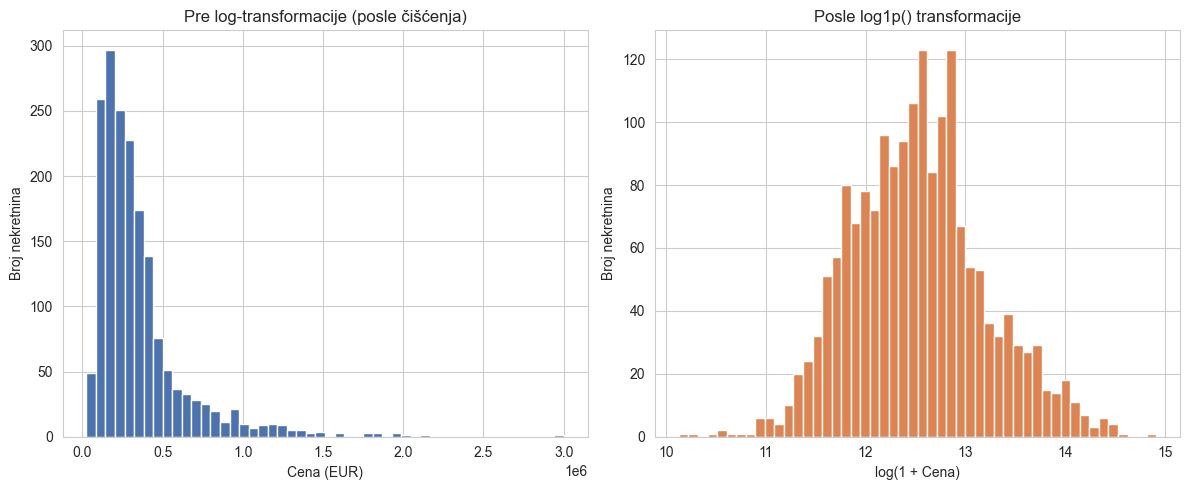

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["price_eur"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Cena (EUR)")
axes[0].set_ylabel("Broj nekretnina")
axes[0].set_title("Pre log-transformacije (posle čišćenja)")

axes[1].hist(np.log1p(df["price_eur"]), bins=50, color="#DD8452", edgecolor="white")
axes[1].set_xlabel("log(1 + Cena)")
axes[1].set_ylabel("Broj nekretnina")
axes[1].set_title("Posle log1p() transformacije")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "log_transformation.png"), dpi=150)
plt.show()

## 7. Preprocessing Pipeline

Cela priprema podataka koja "uči" iz podataka - **imputacija** nedostajućih
numeričkih vrednosti (medijana), imputacija kategorijskih vrednosti
(konstanta `"Nepoznato"`), **skaliranje** (`StandardScaler`) i **one-hot
kodiranje** (`OneHotEncoder`) - nalazi se unutar `ColumnTransformer`, koji
je prvi korak sklearn `Pipeline` objekta svakog modela. Time je, nakon što
se podela na trening/test izvrši pre obrade (odeljak 8), ceo protokol
dosledan: u svakom fold-u unakrsne validacije priprema podataka fituje se
isključivo na delu podataka koji se u tom koraku koristi za treniranje,
bez uvida u validacioni deo, a pipeline se na test skup primenjuje samo
pozivom `predict`.


In [22]:
def build_preprocessor():
    """ColumnTransformer sa kompletnom pripremom podataka:
    - numericke kolone: imputacija medijanom + StandardScaler
    - kategorijske kolone (uklj. pogodnosti 'navedeno'/'nije navedeno'):
      imputacija konstantom 'Nepoznato' + OneHotEncoder."""
    return ColumnTransformer(transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), NUMERIC_FEATURES + BINARY_FEATURES),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Nepoznato")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL_FEATURES + AMENITY_FEATURES),
    ])


def make_pipeline(estimator):
    """Kompletan sklearn Pipeline: priprema podataka + estimator.
    Fituje se isključivo na trening podacima (ceo trening skup ili deo
    fold-a u unakrsnoj validaciji)."""
    return Pipeline([
        ("preprocessing", build_preprocessor()),
        ("model", estimator),
    ])


def to_dense(arr):
    """Sparse matricu (posle one-hot enkodiranja) pretvara u gust niz -
    potrebno za Keras i SHAP."""
    return arr.toarray() if hasattr(arr, "toarray") else np.asarray(arr)


## 8. Train/Test Split

Podaci se dele na **train (80%)** i **test (20%)** skup, uz fiksiran
`random_state` radi reproduktivnosti. Podela se izvršava **pre imputacije
i bilo koje druge obrade**: `X` sadrži sirove (neoobrađene) kolone, a sve
korake pripreme podataka (imputacija, skaliranje, one-hot kodiranje)
obavlja pipeline svakog modela (odeljak 7). Time je garantovano da
informacije iz test skupa ne mogu uticati ni na imputaciju, ni na
skaliranje, ni na enkodiranje.

Test skup se koristi **isključivo jednom, na samom kraju**, za finalno
poređenje svih modela - nijedan model ga ne vidi ni tokom treniranja, ni
tokom hiperparametarskog podešavanja (odeljak 17), ni tokom unakrsne
validacije (odeljak 9).


In [23]:
feature_cols = NUMERIC_FEATURES + BINARY_FEATURES + AMENITY_FEATURES + CATEGORICAL_FEATURES
X = df[feature_cols].copy()
y = df[TARGET].values.astype(float)

# NEOBRADJENI podaci se dele na trening i test skup PRE imputacije,
# skaliranja i kodiranja - te korake obavlja pipeline svakog modela
# (odeljak 7), odvojeno za trening i test skup.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

y_train_log = np.log1p(y_train)

print(f"Trening skup: {X_train.shape[0]} primera x {X_train.shape[1]} sirovih karakteristika")
print(f"Test skup:    {X_test.shape[0]} primera")
X_train.head(3)


Trening skup: 1420 primera x 17 sirovih karakteristika
Test skup:    356 primera


,area_sqm,rooms_num,bathrooms_num,floor_num,extra_features_count,distance_from_center,rooms_per_m2,is_new,elevator,balcony,terrace,basement,furnished,typology,heating,municipality,neighborhood
486,77.0,3.0,2.0,5.0,2,2.474129,0.038961,0,navedeno,nije navedeno,navedeno,nije navedeno,nije navedeno,Trosobni stan,Centralizzato,Vračar,Crveni Krst - Južni bulevar
217,128.0,4.0,2.0,0.0,1,19.526367,0.031250,0,nije navedeno,nije navedeno,navedeno,nije navedeno,nije navedeno,Samostalna porodična vila,Centralizzato,Voždovac,Ripanj - Šuplja Stena
22,100.0,4.0,2.0,0.5,0,1.918091,0.040000,0,nije navedeno,nije navedeno,nije navedeno,nije navedeno,nije navedeno,Četvorosobni stan,Autonomo,Vračar,Kalenić - Slavija - Cvetni Trg


## 9. Cross Validation - protokol poređenja

Umesto da se svaki model oceni na osnovu samo jedne slučajne podele
podataka (što unosi visoku varijansu u ocenu, pogotovo na ovako malom
skupu podataka), koristimo **5-struku unakrsnu validaciju (5-Fold Cross
Validation)** nad trening skupom:

- Trening skup se deli na 5 jednakih delova ("foldova").
- Svaki model se trenira 5 puta - svaki put na 4 dela, i ocenjuje na
  preostalom (petom) delu koji nije video.
- **Unakrsnoj validaciji se prosleđuju neoobrađeni podaci `X_train` i
  cela pipeline** - u svakom fold-u se kompletan pipeline (imputacija,
  skaliranje, one-hot kodiranje + model) ponovo fituje isključivo na
  trening delu tog fold-a, tako da priprema podataka nema uvida u
  validacioni deo (npr. medijana za imputaciju računa se bez njega).
- Prosek i standardna devijacija ovih 5 ocena daju znatno pouzdaniju
  procenu učinka modela nego jedan train/test split: smanjuju varijansu
  procene i direktno pokazuju stabilnost modela (koriste se za poređenje
  modela u odeljcima 18 i 20).

**Isti `KFold` objekat (isti `random_state`, isti splitovi) koristi se za
SVE modele** - ključno za fer poređenje, jer svi modeli ocenjuju na
identičnim rasporedima podataka.


In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def mean_absolute_percentage_error(y_true, y_pred):
    """MAPE (%) - prosečna apsolutna relativna greška."""
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)


def cv_evaluate(make_estimator_fn, X, y_log, kf):
    """5-fold CV nad NEOBRADJENIM podacima.

    U svakom fold-u se kompletan pipeline (imputacija + skaliranje +
    one-hot enkodiranje + model) ponovo fituje SAMO na trening delu tog
    fold-a, tako da priprema podataka nema uvid u validacioni deo."""
    maes, rmses, r2s, mapes = [], [], [], []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_log, y_val_log = y_log[train_idx], y_log[val_idx]

        pipe = make_pipeline(make_estimator_fn())
        pipe.fit(X_tr, y_tr_log)

        pred = np.expm1(np.asarray(pipe.predict(X_val)).ravel())
        y_val_real = np.expm1(y_val_log)
        maes.append(mean_absolute_error(y_val_real, pred))
        rmses.append(np.sqrt(mean_squared_error(y_val_real, pred)))
        r2s.append(r2_score(y_val_real, pred))
        mapes.append(mean_absolute_percentage_error(y_val_real, pred))
    return {"MAE": np.array(maes), "RMSE": np.array(rmses),
            "R2": np.array(r2s), "MAPE": np.array(mapes)}


def evaluate_holdout(model, X_test, y_test_real):
    """Ocena na nezavisnom test skupu (pipeline/model fitovan na trening
    skupu; predikcija je na log-skali pa se vraća u EUR preko expm1).

    Napomena: `.ravel()` je neophodan jer Keras `model.predict()` vraća
    2D niz oblika (n, 1), za razliku od scikit-learn/XGBoost/itd. modela
    koji vraćaju 1D niz oblika (n,). Bez ravel-a, oduzimanje
    (y_true - y_pred) bi se broadcast-ovalo u (n, n) matricu umesto
    elementarne (n,) razlike, što bi dalo pogrešnu (drastično naduvanu)
    MAPE vrednost specifično za MLP model."""
    pred = np.expm1(np.asarray(model.predict(X_test)).ravel())
    return {
        "MAE": mean_absolute_error(y_test_real, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_real, pred)),
        "R2": r2_score(y_test_real, pred),
        "MAPE": mean_absolute_percentage_error(y_test_real, pred),
    }, pred


# Rezultati svih modela se skupljaju u ove rečnike radi lakšeg poređenja u odeljcima 17-20
results_cv = {}       # {model_name: {"MAE": np.array([...5 foldova...]), ...}}
results_test = {}     # {model_name: {"MAE": float, ...}}  - ocena na nezavisnom test skupu
predictions_test = {} # {model_name: np.array} - predikcije na test skupu (za residual analizu)
timings = {}          # {model_name: sekunde} - vreme treniranja + tuning-a
best_params_all = {}  # {model_name: dict} - najbolji hiperparametri (za tunovane modele)


## 10. Linear Regression

**Prednosti:** izuzetno jednostavan, brz za treniranje, lako interpretabilan
(koeficijenti direktno pokazuju uticaj svake karakteristike), ne zahteva
podešavanje hiperparametara - daje jasnu donju granicu očekivanog učinka.

**Mane:** pretpostavlja linearnu vezu između (log-transformisanih)
karakteristika i cene, ne hvata prirodno nelinearne odnose i interakcije
između karakteristika (npr. da uticaj površine na cenu zavisi od
lokacije) bez ručnog inženjeringa takvih interakcija.

In [25]:
t0 = time.time()

cv_res = cv_evaluate(lambda: LinearRegression(), X_train, y_train_log, kf)

lin_reg_final = make_pipeline(LinearRegression())
lin_reg_final.fit(X_train, y_train_log)
test_res, test_pred = evaluate_holdout(lin_reg_final, X_test, y_test)

timings["Linear Regression"] = time.time() - t0
results_cv["Linear Regression"] = cv_res
results_test["Linear Regression"] = test_res
predictions_test["Linear Regression"] = test_pred

print("=== Linear Regression ===")
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")


=== Linear Regression ===
CV (5-fold):  MAE=84,515±6,605  R²=0.7065±0.0348
Test skup:    MAE=93,564  RMSE=210,748  MAPE=24.60%  R²=0.5062


## 11. Decision Tree

Jednostavan nelinearni model - koristi se kao osnova za razumevanje
ansambala (Random Forest, gradient boosting modeli u narednim odeljcima
su suštinski kombinacije mnogo ovakvih stabala). Podešavamo osnovne
hiperparametre (`max_depth`, `min_samples_split`, `min_samples_leaf`)
pomoću `RandomizedSearchCV` kako bismo sprečili preprilagođavanje
(overfitting) jednog dubokog stabla.

In [26]:
t0 = time.time()

dt_param_dist = {
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
}
# Tuning se vrsi nad CELOM pipeline (priprema podataka + model), na
# neoobradjenim X_train podacima: priprema podataka obavlja se odvojeno
# u svakom internom fold-u, bez uvida u validacioni deo.
dt_search = RandomizedSearchCV(
    make_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    param_distributions={f"model__{k}": v for k, v in dt_param_dist.items()},
    n_iter=15, cv=3,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
dt_search.fit(X_train, y_train_log)
best_params_all["Decision Tree"] = {k.replace("model__", ""): v
                                    for k, v in dt_search.best_params_.items()}

cv_res = cv_evaluate(
    lambda: DecisionTreeRegressor(random_state=RANDOM_STATE, **best_params_all["Decision Tree"]),
    X_train, y_train_log, kf,
)
dt_final = make_pipeline(
    DecisionTreeRegressor(random_state=RANDOM_STATE, **best_params_all["Decision Tree"])
)
dt_final.fit(X_train, y_train_log)
test_res, test_pred = evaluate_holdout(dt_final, X_test, y_test)

timings["Decision Tree"] = time.time() - t0
results_cv["Decision Tree"] = cv_res
results_test["Decision Tree"] = test_res
predictions_test["Decision Tree"] = test_pred

print("=== Decision Tree ===")
print("Najbolji hiperparametri:", best_params_all["Decision Tree"])
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")


=== Decision Tree ===
Najbolji hiperparametri: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 8}
CV (5-fold):  MAE=98,978±10,446  R²=0.6351±0.0644
Test skup:    MAE=94,516  RMSE=191,194  MAPE=26.05%  R²=0.5936


## 12. Random Forest

Ansambl (bagging) velikog broja stabala odlučivanja treniranih na
slučajnim poduzorcima podataka i karakteristika - smanjuje varijansu u
odnosu na pojedinačno stablo i prirodno hvata nelinearnosti i interakcije
između karakteristika. Hiperparametri se podešavaju pomoću
`RandomizedSearchCV` (brže od iscrpnog `GridSearchCV` uz sličan kvalitet
rezultata - videti diskusiju u odeljku 17).

In [27]:
t0 = time.time()

rf_param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
rf_search = RandomizedSearchCV(
    make_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
    param_distributions={f"model__{k}": v for k, v in rf_param_dist.items()},
    n_iter=12, cv=3,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train, y_train_log)
best_params_all["Random Forest"] = {k.replace("model__", ""): v
                                    for k, v in rf_search.best_params_.items()}

cv_res = cv_evaluate(
    lambda: RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params_all["Random Forest"]),
    X_train, y_train_log, kf,
)
rf_final = make_pipeline(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params_all["Random Forest"])
)
rf_final.fit(X_train, y_train_log)
test_res, test_pred = evaluate_holdout(rf_final, X_test, y_test)

timings["Random Forest"] = time.time() - t0
results_cv["Random Forest"] = cv_res
results_test["Random Forest"] = test_res
predictions_test["Random Forest"] = test_pred

print("=== Random Forest ===")
print("Najbolji hiperparametri:", best_params_all["Random Forest"])
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")


=== Random Forest ===
Najbolji hiperparametri: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
CV (5-fold):  MAE=81,788±7,644  R²=0.7316±0.0502
Test skup:    MAE=75,669  RMSE=151,519  MAPE=20.93%  R²=0.7447


## 13. XGBoost

Gradient boosting - stabla se dodaju sekvencijalno, svako novo stablo
uči da ispravi greške prethodnih. Industrijski je standard za tabelarne
podatke (dominira Kaggle takmičenjima). Podešavamo `learning_rate`,
`max_depth`, `subsample`, `colsample_bytree` i `n_estimators`.

In [28]:
t0 = time.time()

xgb_param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    make_pipeline(XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, tree_method="hist")),
    param_distributions={f"model__{k}": v for k, v in xgb_param_dist.items()},
    n_iter=15, cv=3,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_search.fit(X_train, y_train_log)
best_params_all["XGBoost"] = {k.replace("model__", ""): v
                              for k, v in xgb_search.best_params_.items()}

cv_res = cv_evaluate(
    lambda: XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
                         **best_params_all["XGBoost"]),
    X_train, y_train_log, kf,
)
xgb_final = make_pipeline(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
                 **best_params_all["XGBoost"])
)
xgb_final.fit(X_train, y_train_log)
test_res, test_pred = evaluate_holdout(xgb_final, X_test, y_test)

timings["XGBoost"] = time.time() - t0
results_cv["XGBoost"] = cv_res
results_test["XGBoost"] = test_res
predictions_test["XGBoost"] = test_pred

print("=== XGBoost ===")
print("Najbolji hiperparametri:", best_params_all["XGBoost"])
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")


=== XGBoost ===
Najbolji hiperparametri: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
CV (5-fold):  MAE=78,047±8,313  R²=0.7458±0.0564
Test skup:    MAE=71,318  RMSE=143,500  MAPE=20.27%  R²=0.7710


## 14. CatBoost

Takođe gradient boosting, ali sa nekoliko ključnih prednosti za ovaj
skup podataka:
- **odličan za tabelarne podatke** - ordered boosting smanjuje overfitting
  u odnosu na klasičan gradient boosting;
- **nativna podrška kategorijskih atributa** - ume interno da obradi
  kategorije (npr. `neighborhood` sa 128 vrednosti) bez potrebe za
  ručnim one-hot enkodiranjem (mi ipak koristimo isti preprocessing
  pipeline kao i za ostale modele radi fer poređenja);
- **mala potreba za preprocessing-om** - robustan je na retke kategorije
  i nedostajuće vrednosti, koje smo već rešili u odeljku 4.

In [29]:
t0 = time.time()

cat_param_dist = {
    "iterations": [200, 300, 500],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7],
}
cat_search = RandomizedSearchCV(
    make_pipeline(CatBoostRegressor(random_state=RANDOM_STATE, verbose=0)),
    param_distributions={f"model__{k}": v for k, v in cat_param_dist.items()},
    n_iter=10, cv=3,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
cat_search.fit(X_train, y_train_log)
best_params_all["CatBoost"] = {k.replace("model__", ""): v
                               for k, v in cat_search.best_params_.items()}

cv_res = cv_evaluate(
    lambda: CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, **best_params_all["CatBoost"]),
    X_train, y_train_log, kf,
)
cat_final = make_pipeline(
    CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, **best_params_all["CatBoost"])
)
cat_final.fit(X_train, y_train_log)
test_res, test_pred = evaluate_holdout(cat_final, X_test, y_test)

timings["CatBoost"] = time.time() - t0
results_cv["CatBoost"] = cv_res
results_test["CatBoost"] = test_res
predictions_test["CatBoost"] = test_pred

print("=== CatBoost ===")
print("Najbolji hiperparametri:", best_params_all["CatBoost"])
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")


=== CatBoost ===
Najbolji hiperparametri: {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 300, 'depth': 4}
CV (5-fold):  MAE=76,916±6,758  R²=0.7632±0.0452
Test skup:    MAE=73,694  RMSE=151,204  MAPE=20.45%  R²=0.7458


## 15. LightGBM

Još jedna gradient boosting implementacija, sa fokusom na brzinu i
efikasnost:
- **histogram-based trees** - vrednosti karakteristika se grupišu u
  "kante" (bins) pre traženja najboljeg razdvajanja čvora, što drastično
  ubrzava treniranje u odnosu na klasičan pristup (razmatranje svake
  jedinstvene vrednosti);
- **veoma brz trening** - u našim eksperimentima (odeljak 17) LightGBM
  je bio ubedljivo najbrži od svih tunovanih modela;
- **mala potrošnja memorije** - histogram-based pristup zahteva znatno
  manje memorije od standardnog gradient boosting-a, bitno za veće
  skupove podataka (iako na ovom, relativno malom skupu, ova prednost
  nije presudna).

In [30]:
t0 = time.time()

lgbm_param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [-1, 5, 8, 12],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.8, 1.0],
}
lgbm_search = RandomizedSearchCV(
    make_pipeline(LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbose=-1)),
    param_distributions={f"model__{k}": v for k, v in lgbm_param_dist.items()},
    n_iter=15, cv=3,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
lgbm_search.fit(X_train, y_train_log)
best_params_all["LightGBM"] = {k.replace("model__", ""): v
                               for k, v in lgbm_search.best_params_.items()}

cv_res = cv_evaluate(
    lambda: LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                          **best_params_all["LightGBM"]),
    X_train, y_train_log, kf,
)
lgbm_final = make_pipeline(
    LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                  **best_params_all["LightGBM"])
)
lgbm_final.fit(X_train, y_train_log)
test_res, test_pred = evaluate_holdout(lgbm_final, X_test, y_test)

timings["LightGBM"] = time.time() - t0
results_cv["LightGBM"] = cv_res
results_test["LightGBM"] = test_res
predictions_test["LightGBM"] = test_pred

print("=== LightGBM ===")
print("Najbolji hiperparametri:", best_params_all["LightGBM"])
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")


=== LightGBM ===
Najbolji hiperparametri: {'subsample': 0.7, 'num_leaves': 15, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.03}
CV (5-fold):  MAE=81,496±8,199  R²=0.7317±0.0438
Test skup:    MAE=69,841  RMSE=139,249  MAPE=19.96%  R²=0.7844


## 16. MLP neuronska mreža

### 16.1 Poređenje arhitektura

Pre nego što izaberemo finalnu arhitekturu, isprobavamo nekoliko
kombinacija broja neurona, aktivacionih funkcija, Dropout-a,
BatchNormalization-a i optimizatora, na jednom brzom train/validation
splitu (radi vremena izvršavanja - finalna arhitektura se zatim ocenjuje
punim protokolom: 5-fold CV + nezavisan test skup). Mreža prima
karakteristike dobijene iz pipeline-a za pripremu podataka, pri čemu se
transformer fituje samo na delu podataka koji se koristi za treniranje.


In [31]:
# Train/validation podela na sirovim podacima; transformer se fituje
# samo na trening delu, a primenjuje i na validacioni deo
X_tr_exp_df, X_val_exp_df, y_tr_log_exp, y_val_log_exp = train_test_split(
    X_train, y_train_log, test_size=0.15, random_state=RANDOM_STATE
)
prep_exp = build_preprocessor()
X_tr_exp = to_dense(prep_exp.fit_transform(X_tr_exp_df))
X_val_exp = to_dense(prep_exp.transform(X_val_exp_df))
y_val_real_exp = np.expm1(y_val_log_exp)


def make_experimental_model(blocks, activation, optimizer_cls, lr):
    model_layers = [layers.Input(shape=(X_tr_exp.shape[1],))]
    for units, drop, use_bn in blocks:
        model_layers.append(layers.Dense(units, activation=activation))
        if use_bn:
            model_layers.append(layers.BatchNormalization())
        if drop:
            model_layers.append(layers.Dropout(drop))
    model_layers.append(layers.Dense(1, activation="linear"))
    model = keras.Sequential(model_layers)
    model.compile(optimizer=optimizer_cls(learning_rate=lr), loss="mean_squared_error", metrics=["mae"])
    return model


architectures = {
    "64-32, ReLU, Dropout 0.2, bez BatchNorm": dict(
        blocks=[(64, 0.2, False), (32, 0.0, False)], activation="relu",
        optimizer_cls=keras.optimizers.Adam, lr=0.001),
    "128-64-32, ReLU, BatchNorm + Dropout": dict(
        blocks=[(128, 0.3, True), (64, 0.2, True), (32, 0.0, False)], activation="relu",
        optimizer_cls=keras.optimizers.Adam, lr=0.001),
    "64-32, ReLU, BatchNorm + Dropout 0.1": dict(
        blocks=[(64, 0.1, True), (32, 0.1, False)], activation="relu",
        optimizer_cls=keras.optimizers.Adam, lr=0.001),
    "64-32, ELU, Dropout 0.2, niži learning rate": dict(
        blocks=[(64, 0.2, False), (32, 0.0, False)], activation="elu",
        optimizer_cls=keras.optimizers.Adam, lr=0.0005),
    "128-64, ReLU, Dropout 0.3, RMSprop": dict(
        blocks=[(128, 0.3, False), (64, 0.2, False)], activation="relu",
        optimizer_cls=keras.optimizers.RMSprop, lr=0.001),
}

architecture_results = []
for name, cfg in architectures.items():
    model = make_experimental_model(cfg["blocks"], cfg["activation"], cfg["optimizer_cls"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    hist = model.fit(X_tr_exp, y_tr_log_exp, validation_data=(X_val_exp, y_val_log_exp),
                      epochs=150, batch_size=32, callbacks=[es], verbose=0)
    pred = np.expm1(model.predict(X_val_exp, verbose=0).ravel())
    architecture_results.append({
        "Arhitektura": name,
        "R2 (validacija)": r2_score(y_val_real_exp, pred),
        "MAE (validacija)": mean_absolute_error(y_val_real_exp, pred),
        "MAPE (validacija) %": mean_absolute_percentage_error(y_val_real_exp, pred),
        "Broj epoha": len(hist.history["loss"]),
    })

architecture_comparison = pd.DataFrame(architecture_results).sort_values("R2 (validacija)", ascending=False)
architecture_comparison


,Arhitektura,R2 (validacija),MAE (validacija),MAPE (validacija) %,Broj epoha
3,"64-32, ELU, Dropout 0.2, niži learning rate",0.754721,93358.162568,25.153250,63
4,"128-64, ReLU, Dropout 0.3, RMSprop",0.533723,109106.248808,29.965165,53
0,"64-32, ReLU, Dropout 0.2, bez BatchNorm",0.483714,115908.140277,28.776580,39
2,"64-32, ReLU, BatchNorm + Dropout 0.1",0.447159,156339.234962,49.199117,83
1,"128-64-32, ReLU, BatchNorm + Dropout",0.288446,151021.900794,41.653564,59


**Zapažanje:** BatchNormalization u kombinaciji sa Dropout-om
konzistentno **pogoršava** rezultate na ovako malom skupu podataka
(~1.500 trening primera) - poznat je fenomen da BatchNorm i Dropout mogu
međusobno "smetati" (BatchNorm računa statistike po mini-batch-u, a
Dropout unosi dodatan šum u te iste statistike), a mali batch-evi na
malom skupu podataka dodatno pojačavaju ovu nestabilnost. Zbog toga
finalna arhitektura **ne koristi BatchNormalization**. Najbolje rezultate
daje jednostavnija mreža sa ELU aktivacijom, umerenim Dropout-om (0.2) i
nešto nižim learning rate-om (0.0005) - ova konfiguracija se koristi kao
finalna arhitektura ispod.

### 16.2 Finalna arhitektura

```
Input Layer   (one-hot enkodirane karakteristike posle pipeline pripreme)
  ↓
Dense Layer   - 64 neurona (ELU)
  ↓
Dropout       - 0.2
  ↓
Dense Layer   - 32 neurona (ELU)
  ↓
Output Layer  - 1 neuron (predviđena log-cena)
```

**Obrazloženje:**
- **64 → 32 neurona:** opadajući "levak" - dovoljan kapacitet da nauči
  nelinearne odnose (npr. interakciju lokacije i površine) bez
  prevelikog rizika od overfitting-a na ~1.400 trening primera.
- **ELU aktivacija:** u poređenju iz odeljka 16.1, ELU je dala bolje
  rezultate od ReLU na ovom skupu podataka - za razliku od ReLU, ELU ima
  negativan izlaz za negativne ulaze (blaže "umire" gradijent), što može
  pomoći stabilnosti na malom skupu podataka.
- **Dropout(0.2):** nasumično gasi 20% neurona tokom treniranja - umerena
  regularizacija protiv overfitting-a, bez usporavanja konvergencije.
- **Adam optimizator, learning_rate=0.0005:** niži learning rate od
  podrazumevanog (0.001) daje stabilniju konvergenciju na ovom malom
  skupu podataka (potvrđeno eksperimentom u 16.1).
- **Funkcija gubitka:** Mean Squared Error (MSE) na log-transformisanoj ceni.
- **EarlyStopping:** prati `val_loss`, `patience=15`, vraća težine iz
  najbolje epohe (`restore_best_weights=True`) - sprečava overfitting bez
  potrebe za ručnim biranjem broja epoha.


In [32]:
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="elu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="elu"),
        layers.Dense(1, activation="linear"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
                  loss="mean_squared_error", metrics=["mae"])
    return model

### 16.3 Cross Validation za MLP

Pošto Keras model nije direktno kompatibilan sa scikit-learn
`Pipeline`/`cv_evaluate` funkcijama, implementiramo ekvivalentnu 5-fold CV
petlju ručno, koristeći **isti `kf` objekat** (iste foldove) kao i za sve
ostale modele - radi fer poređenja (odeljak 18). Kao i kod drugih modela,
transformer za pripremu podataka **fituje se u svakom fold-u samo na
trening delu** (neoobrađeni `X_train` se deli po indeksima foldova), a
zatim transformiše i trening i validacioni deo. Unutar svakog fold-a,
dodatnih 10% trening dela se izdvaja kao validacija za EarlyStopping.


In [33]:
t0 = time.time()

maes, rmses, r2s, mapes = [], [], [], []
for fold_i, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr_log, y_val_log = y_train_log[tr_idx], y_train_log[val_idx]

    # Priprema podataka se fituje SAMO na trening delu fold-a
    prep_fold = build_preprocessor()
    X_tr_proc = to_dense(prep_fold.fit_transform(X_tr))
    X_val_proc = to_dense(prep_fold.transform(X_val))

    X_tr2, X_es, y_tr2_log, y_es_log = train_test_split(
        X_tr_proc, y_tr_log, test_size=0.1, random_state=RANDOM_STATE
    )
    model = build_mlp(X_tr_proc.shape[1])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    model.fit(X_tr2, y_tr2_log, validation_data=(X_es, y_es_log),
              epochs=150, batch_size=32, callbacks=[es], verbose=0)

    pred = np.expm1(model.predict(X_val_proc, verbose=0).ravel())
    y_val_real = np.expm1(y_val_log)
    maes.append(mean_absolute_error(y_val_real, pred))
    rmses.append(np.sqrt(mean_squared_error(y_val_real, pred)))
    r2s.append(r2_score(y_val_real, pred))
    mapes.append(mean_absolute_percentage_error(y_val_real, pred))
    print(f"Fold {fold_i + 1}/5 - epoha zaustavljanja: {len(model.history.history['loss'])}")

mlp_cv_res = {"MAE": np.array(maes), "RMSE": np.array(rmses), "R2": np.array(r2s), "MAPE": np.array(mapes)}
results_cv["MLP"] = mlp_cv_res

print()
print(f"CV (5-fold):  MAE={mlp_cv_res['MAE'].mean():,.0f}±{mlp_cv_res['MAE'].std():,.0f}  "
      f"R²={mlp_cv_res['R2'].mean():.4f}±{mlp_cv_res['R2'].std():.4f}")


Fold 1/5 - epoha zaustavljanja: 68


Fold 2/5 - epoha zaustavljanja: 80


Fold 3/5 - epoha zaustavljanja: 114


Fold 4/5 - epoha zaustavljanja: 89


Fold 5/5 - epoha zaustavljanja: 54

CV (5-fold):  MAE=85,190±8,598  R²=0.7055±0.0547


### 16.4 Finalni MLP model (treniran na celom trening skupu)

Treniranje zaustavljeno na epohi: 47
Najbolja epoha (min val_loss):    32


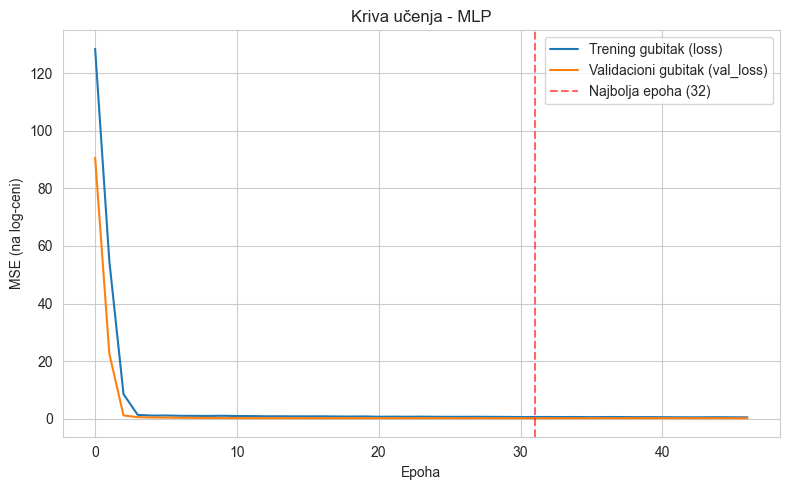

In [34]:
# Finalni MLP: podela trening skupa na deo za treniranje i manji deo za
# EarlyStopping; transformer se fituje SAMO na delu za treniranje
X_tr2_df, X_es_df, y_tr2_log, y_es_log = train_test_split(
    X_train, y_train_log, test_size=0.1, random_state=RANDOM_STATE
)
mlp_preprocessor = build_preprocessor()
X_tr2 = to_dense(mlp_preprocessor.fit_transform(X_tr2_df))
X_es = to_dense(mlp_preprocessor.transform(X_es_df))

mlp_final = build_mlp(X_tr2.shape[1])
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
mlp_history = mlp_final.fit(
    X_tr2, y_tr2_log, validation_data=(X_es, y_es_log),
    epochs=150, batch_size=32, callbacks=[early_stopping], verbose=0,
)

stopped_epoch = len(mlp_history.history["loss"])
best_epoch = int(np.argmin(mlp_history.history["val_loss"])) + 1
print(f"Treniranje zaustavljeno na epohi: {stopped_epoch}")
print(f"Najbolja epoha (min val_loss):    {best_epoch}")

plt.figure(figsize=(8, 5))
plt.plot(mlp_history.history["loss"], label="Trening gubitak (loss)")
plt.plot(mlp_history.history["val_loss"], label="Validacioni gubitak (val_loss)")
plt.axvline(best_epoch - 1, color="red", linestyle="--", alpha=0.6, label=f"Najbolja epoha ({best_epoch})")
plt.xlabel("Epoha")
plt.ylabel("MSE (na log-ceni)")
plt.title("Kriva učenja - MLP")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "mlp_learning_curve.png"), dpi=150)
plt.show()


In [35]:
X_test_mlp = to_dense(mlp_preprocessor.transform(X_test))
test_res, test_pred = evaluate_holdout(mlp_final, X_test_mlp, y_test)
results_test["MLP"] = test_res
predictions_test["MLP"] = test_pred
# vreme obuhvata CV petlju i finalno treniranje (t0 iz odeljka 16.3)
timings["MLP"] = time.time() - t0

print("=== MLP neuronska mreža ===")
print(f"Test skup:  MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")

mlp_final.save(os.path.join(MODEL_DIR, "mlp_final.keras"))


 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


=== MLP neuronska mreža ===
Test skup:  MAE=85,804  RMSE=183,237  MAPE=22.93%  R²=0.6267


## 17. Pregled hiperparametarskog podešavanja

Za sve "ozbiljnije" modele (Decision Tree, Random Forest, XGBoost,
CatBoost, LightGBM) korišćen je `RandomizedSearchCV`. Pretraga se vrši nad
**celom pipeline** (priprema podataka + model), na **neoobrađenim
podacima** `X_train` - unutar interne 3-fold validacije priprema podataka
obavlja se odvojeno u svakom fold-u, bez uticaja validacionog dela na
imputaciju, skaliranje i enkodiranje.

**GridSearchCV vs. RandomizedSearchCV:**

| | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| Pristup | Isprobava **sve** kombinacije parametara u mreži | Isprobava **slučajan uzorak** od `n_iter` kombinacija |
| Garancija | Garantovano nalazi najbolju kombinaciju **unutar zadate mreže** | Ne garantuje globalni optimum, ali obično nalazi rešenje blisko optimalnom |
| Vreme izvršavanja | Raste **eksponencijalno** sa brojem parametara i vrednosti po parametru | Raste **linearno** sa `n_iter`, nezavisno od veličine prostora pretrage |
| Kada koristiti | Mali prostor pretrage (par parametara, par vrednosti) | Veći prostor pretrage, ograničeno vreme/resursi (naš slučaj - 4-5 parametara po modelu) |

U ovom radu korišćen je `RandomizedSearchCV` upravo zato što svaki model
ima 4-5 hiperparametara sa po 3-6 mogućih vrednosti - iscrpna
`GridSearchCV` pretraga bi zahtevala stotine do hiljade kombinacija po
modelu, dok `RandomizedSearchCV` sa 10-15 slučajnih pokušaja (uz
unutrašnju 3-fold CV radi ocene svake kombinacije) daje uporediv kvalitet
uz znatno kraće vreme izvršavanja.


In [36]:
best_params_table = pd.DataFrame([
    {"Model": name, "Najbolji hiperparametri": str(params)}
    for name, params in best_params_all.items()
])
best_params_table

,Model,Najbolji hiperparametri
0,Decision Tree,"{'min_samples_split': 10, 'min_samples_leaf': ..."
1,Random Forest,"{'n_estimators': 400, 'min_samples_split': 2, ..."
2,XGBoost,"{'subsample': 0.7, 'n_estimators': 300, 'max_d..."
3,CatBoost,"{'learning_rate': 0.05, 'l2_leaf_reg': 1, 'ite..."
4,LightGBM,"{'subsample': 0.7, 'num_leaves': 15, 'n_estima..."


## 18. Evaluacija i poređenje modela

Glavna tabela poređenja - za svaki model prikazujemo i ocenu na
**nezavisnom test skupu** (glavni kriterijum poređenja, jer ga nijedan
model nije video ni tokom treniranja ni tokom tuning-a) i **prosek ± std
unakrsne validacije** (5-fold, na trening skupu - pokazuje koliko je
ocena modela stabilna/pouzdana).

In [37]:
comparison_rows = []
for name in results_test:
    t = results_test[name]
    cv = results_cv[name]
    comparison_rows.append({
        "Model": name,
        "Test MAE (EUR)": round(t["MAE"], 0),
        "Test RMSE (EUR)": round(t["RMSE"], 0),
        "Test MAPE (%)": round(t["MAPE"], 2),
        "Test R2": round(t["R2"], 4),
        "CV MAE (EUR)": f"{cv['MAE'].mean():,.0f} ± {cv['MAE'].std():,.0f}",
        "CV RMSE (EUR)": f"{cv['RMSE'].mean():,.0f} ± {cv['RMSE'].std():,.0f}",
        "CV MAPE (%)": f"{cv['MAPE'].mean():.2f} ± {cv['MAPE'].std():.2f}",
        "CV R2": f"{cv['R2'].mean():.4f} ± {cv['R2'].std():.4f}",
        "Vreme treniranja (s)": round(timings.get(name, float("nan")), 1),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Test R2", ascending=False).reset_index(drop=True)
comparison_df


,Model,Test MAE (EUR),Test RMSE (EUR),Test MAPE (%),Test R2,CV MAE (EUR),CV RMSE (EUR),CV MAPE (%),CV R2,Vreme treniranja (s)
0,LightGBM,69841.0,139249.0,19.96,0.7844,"81,496 ± 8,199","146,951 ± 23,638",22.91 ± 1.81,0.7317 ± 0.0438,2.4
1,XGBoost,71318.0,143500.0,20.27,0.7710,"78,047 ± 8,313","142,671 ± 25,410",21.75 ± 1.82,0.7458 ± 0.0564,4.7
2,CatBoost,73694.0,151204.0,20.45,0.7458,"76,916 ± 6,758","137,768 ± 22,466",21.56 ± 1.29,0.7632 ± 0.0452,35.3
3,Random Forest,75669.0,151519.0,20.93,0.7447,"81,788 ± 7,644","146,779 ± 24,311",23.04 ± 1.64,0.7316 ± 0.0502,39.0
4,MLP,85804.0,183237.0,22.93,0.6267,"85,190 ± 8,598","153,961 ± 26,567",23.54 ± 1.68,0.7055 ± 0.0547,43.7
5,Decision Tree,94516.0,191194.0,26.05,0.5936,"98,978 ± 10,446","170,854 ± 25,441",28.79 ± 2.27,0.6351 ± 0.0644,6.1
6,Linear Regression,93564.0,210748.0,24.60,0.5062,"84,515 ± 6,605","153,598 ± 21,054",23.61 ± 1.47,0.7065 ± 0.0348,0.2


In [38]:
best_model_name = comparison_df.iloc[0]["Model"]
print(f"Najbolji model po Test R²: {best_model_name}")
comparison_df[["Model", "Test MAE (EUR)", "Test RMSE (EUR)", "Test MAPE (%)", "Test R2"]]

Najbolji model po Test R²: LightGBM


,Model,Test MAE (EUR),Test RMSE (EUR),Test MAPE (%),Test R2
0,LightGBM,69841.0,139249.0,19.96,0.7844
1,XGBoost,71318.0,143500.0,20.27,0.7710
2,CatBoost,73694.0,151204.0,20.45,0.7458
3,Random Forest,75669.0,151519.0,20.93,0.7447
4,MLP,85804.0,183237.0,22.93,0.6267
5,Decision Tree,94516.0,191194.0,26.05,0.5936
6,Linear Regression,93564.0,210748.0,24.60,0.5062


## 19. Vizuelno poređenje modela

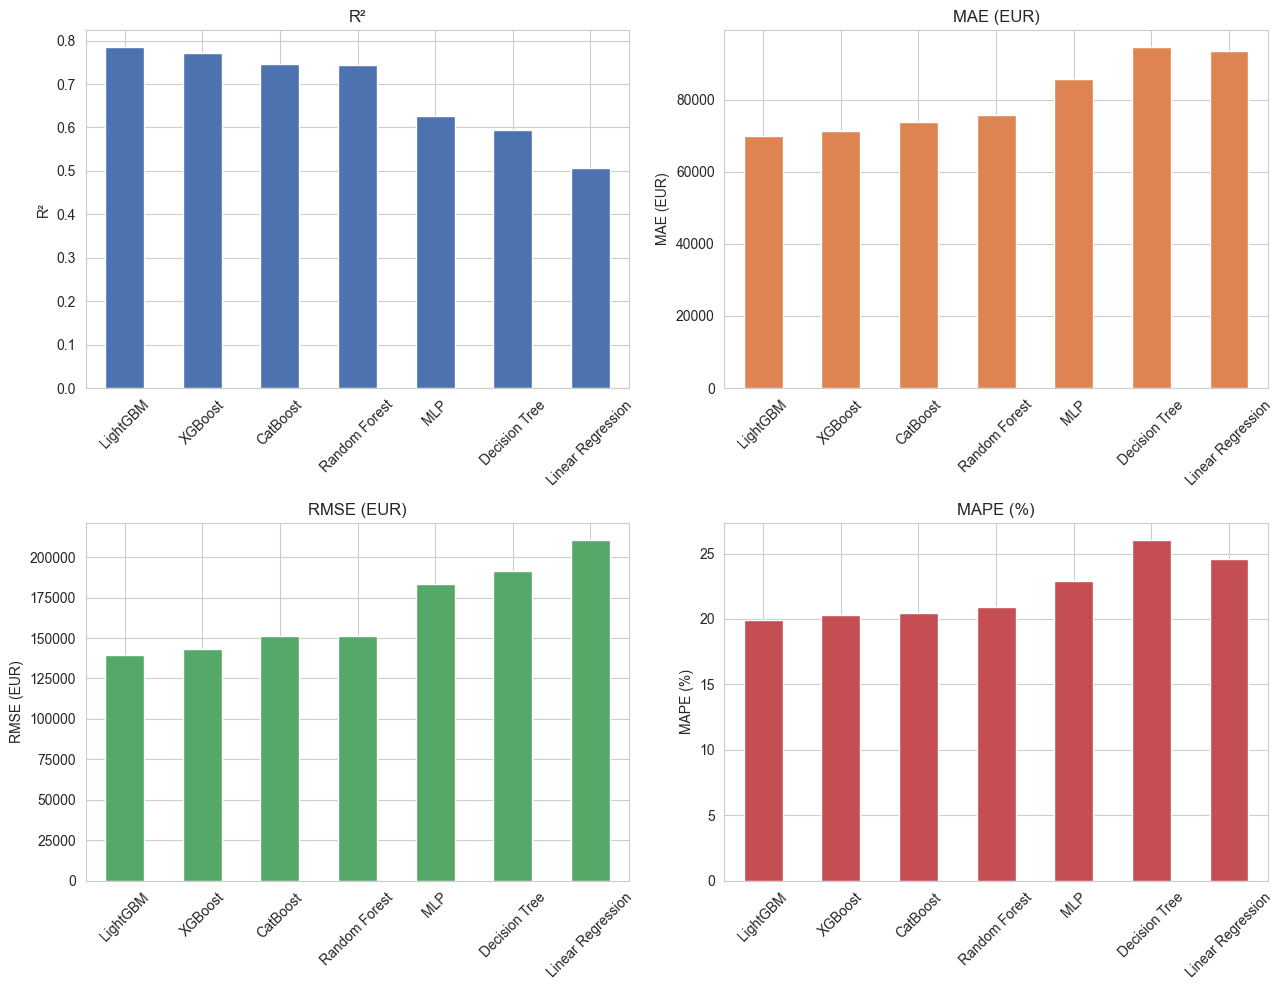

In [39]:
plot_order = comparison_df["Model"].tolist()
metrics_to_plot = [("Test R2", "R²", "#4C72B0"), ("Test MAE (EUR)", "MAE (EUR)", "#DD8452"),
                   ("Test RMSE (EUR)", "RMSE (EUR)", "#55A868"), ("Test MAPE (%)", "MAPE (%)", "#C44E52")]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
for ax, (col, label, color) in zip(axes, metrics_to_plot):
    values = comparison_df.set_index("Model").loc[plot_order, col]
    values.plot(kind="bar", ax=ax, color=color)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "model_comparison_bars.png"), dpi=150)
plt.show()

### Radar chart - normalizovano poređenje svih metrika

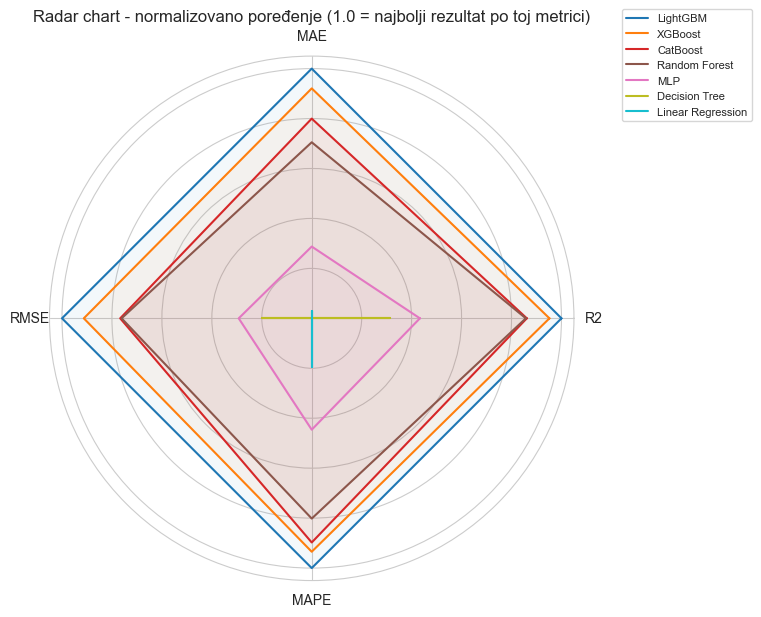

In [40]:
# Normalizacija svih metrika na [0, 1] skalu, gde 1 = najbolji model po toj metrici
radar_metrics = ["Test R2", "Test MAE (EUR)", "Test RMSE (EUR)", "Test MAPE (%)"]
radar_df = comparison_df.set_index("Model")[radar_metrics].copy()

# Za R2, veće je bolje; za MAE/RMSE/MAPE, manje je bolje - invertujemo pre normalizacije
radar_norm = pd.DataFrame(index=radar_df.index)
radar_norm["R2"] = (radar_df["Test R2"] - radar_df["Test R2"].min()) / (radar_df["Test R2"].max() - radar_df["Test R2"].min())
for col, label in [("Test MAE (EUR)", "MAE"), ("Test RMSE (EUR)", "RMSE"), ("Test MAPE (%)", "MAPE")]:
    inv = 1 / radar_df[col]
    radar_norm[label] = (inv - inv.min()) / (inv.max() - inv.min())

categories = list(radar_norm.columns)
n_cats = len(categories)
angles = np.linspace(0, 2 * np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(radar_norm)))
for (model_name, row), color in zip(radar_norm.iterrows(), colors):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=model_name, color=color, linewidth=1.5)
    ax.fill(angles, values, color=color, alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticklabels([])
ax.set_title("Radar chart - normalizovano poređenje (1.0 = najbolji rezultat po toj metrici)")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "model_comparison_radar.png"), dpi=150)
plt.show()

## 20. Poređenje rezultata unakrsne validacije i nezavisnog test skupa

Poređenje modela zasniva se na dva komplementarna pogleda:

1. **Nezavisni test skup** (odeljak 18) - jedna podela podataka koju
   nijedan model nije video ni tokom treniranja, ni tokom
   hiperparametarskog podešavanja; glavni kriterijum poređenja.
2. **Prosek ± standardna devijacija po foldovima 5-struke unakrsne
   validacije** za MAE, RMSE, MAPE i R² (kolone `CV ...` u tabeli iz
   odeljka 18) - pokazuje stabilnost učinka modela i smanjuje varijansu
   procene koju bi donela jedna jedina podela.

Model se smatra boljim ako je dosledno bolji i na test skupu i po proseku
unakrsne validacije; ako su razlike među modelima manje od raspršenosti
ocena po foldovima (standardne devijacije), tretiramo ih kao praktično
neraspoznatljive na ovom skupu podataka.

Statistički testovi razlika između modela (npr. Friedman i Wilcoxon test)
nisu primenjeni: smisleno bi bilo da se sprovode uz ponovljenu unakrsnu
validaciju (više ponavljanja sa različitim rasporedima foldova), čime se
ova analiza namerno ne komplikuje - uporedni prikaz proseka sa standardnom
devijacijom zajedno sa ocenom na nezavisnom test skupu daje dovoljan uvid
u razlike između modela.


## 21. Residual analiza

Za najbolja 3 modela (po Test R²) prikazujemo:
- **Residual plot** (reziduala vs. predikcija),
- **Predicted vs. Actual** scatter,
- **Histogram reziduala**,
- **QQ plot** (proverava da li su reziduali približno normalno distribuirani).

Top 3 modela za residual analizu: ['LightGBM', 'XGBoost', 'CatBoost']


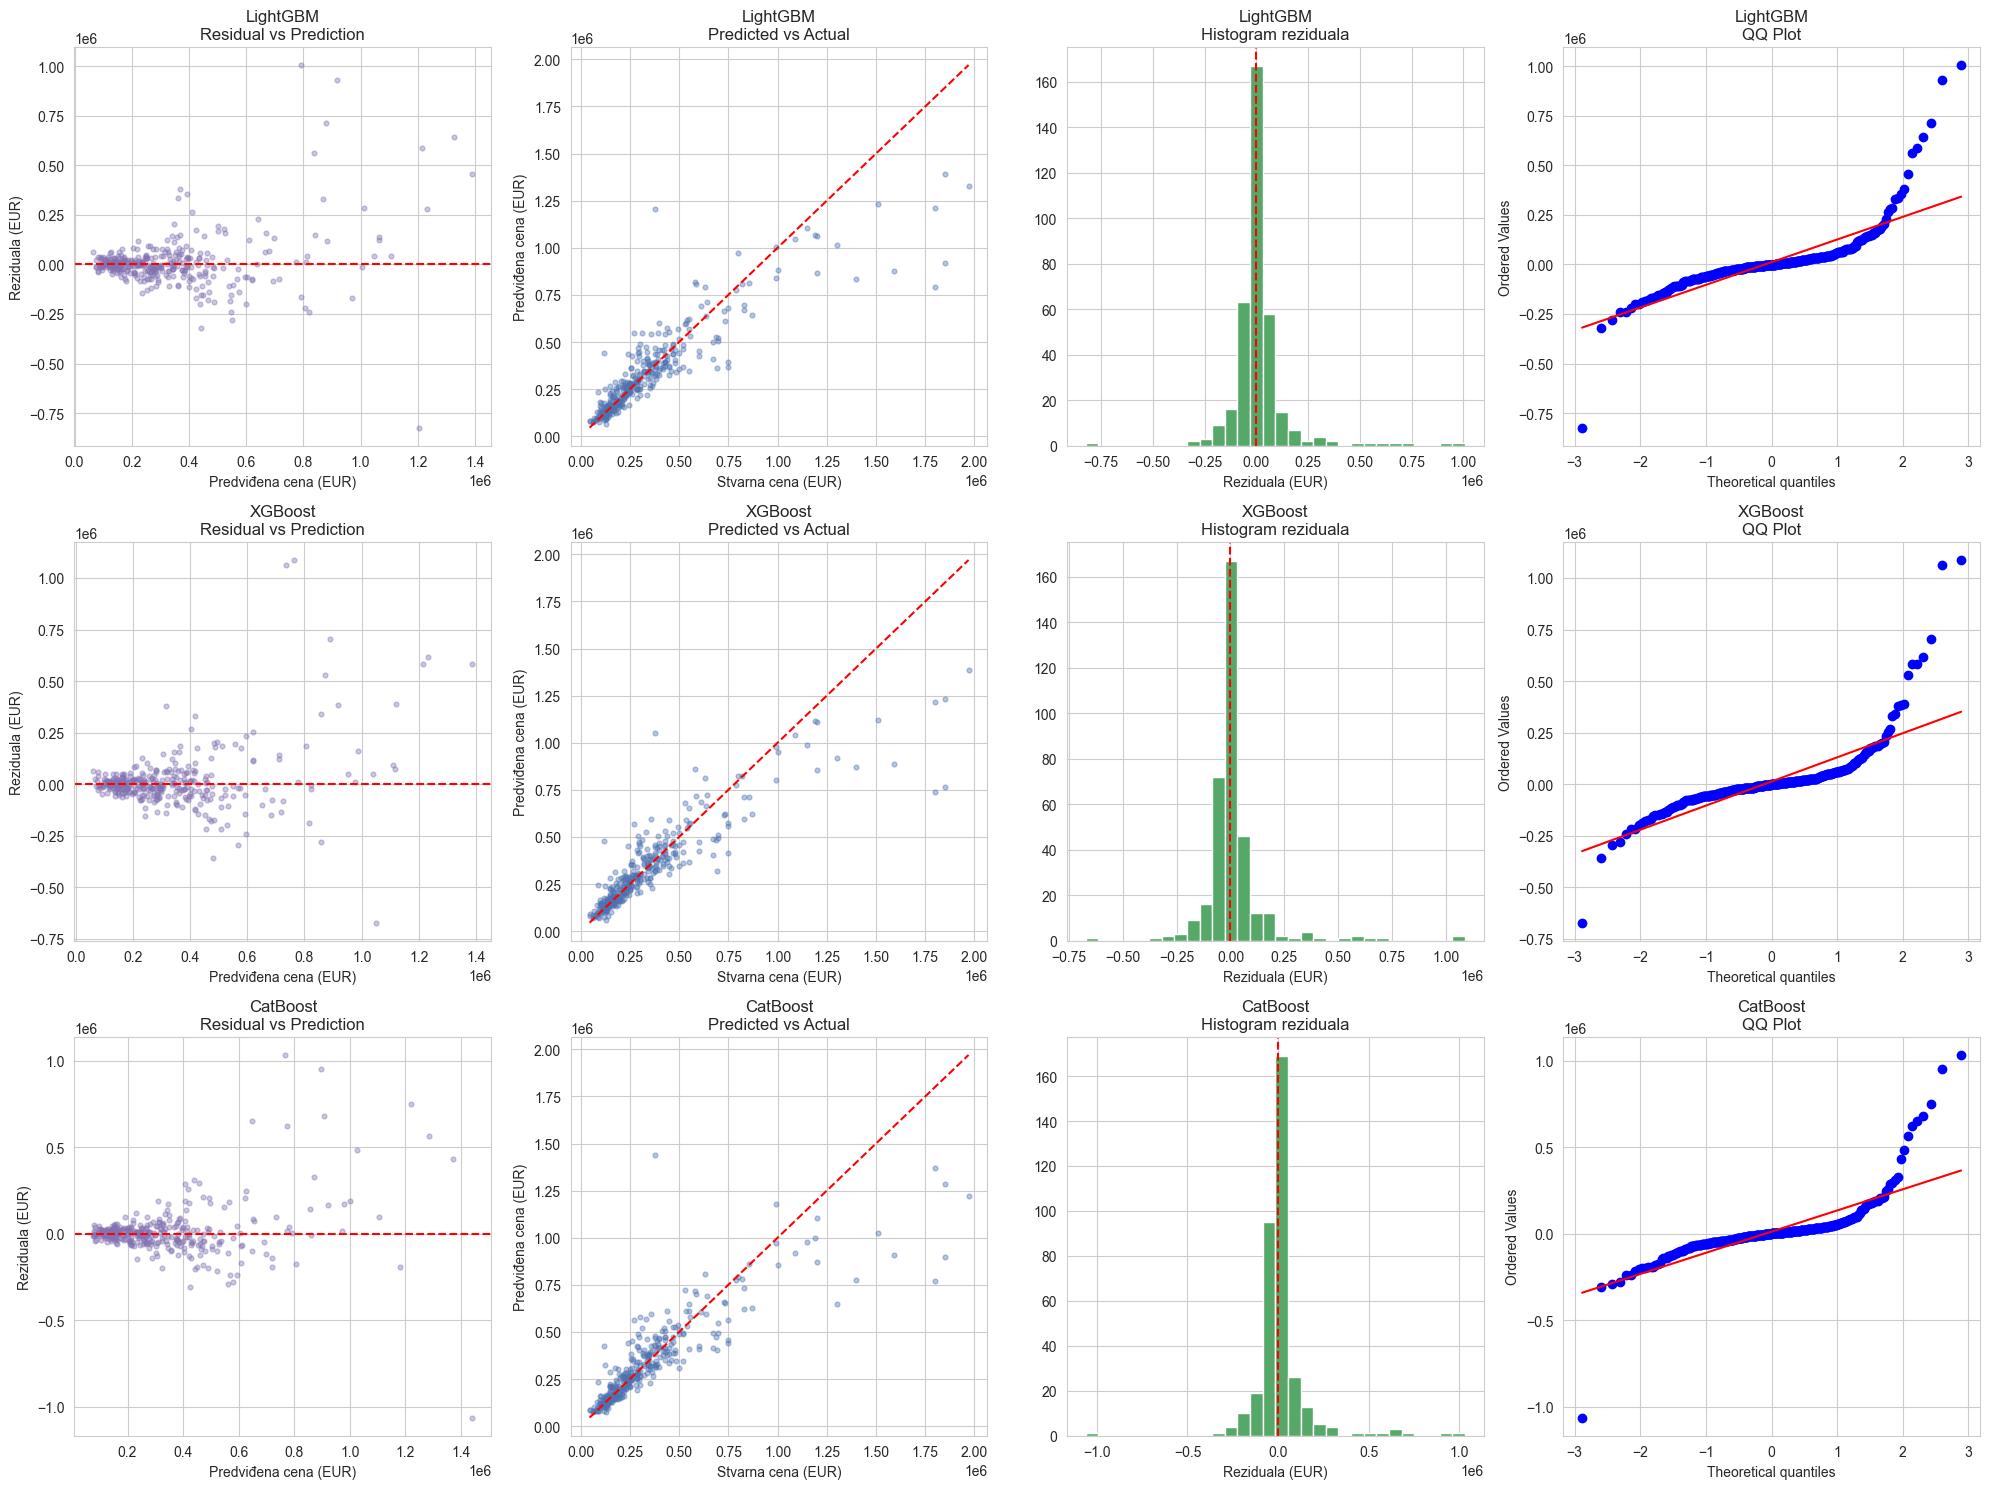

In [41]:
top3_models = comparison_df["Model"].head(3).tolist()
print("Top 3 modela za residual analizu:", top3_models)

fig, axes = plt.subplots(len(top3_models), 4, figsize=(20, 5 * len(top3_models)))

for i, model_name in enumerate(top3_models):
    pred = predictions_test[model_name]
    residuals = y_test - pred

    # 1) Residual vs Prediction
    axes[i, 0].scatter(pred, residuals, alpha=0.4, s=12, color="#8172B2")
    axes[i, 0].axhline(0, color="red", linestyle="--")
    axes[i, 0].set_xlabel("Predviđena cena (EUR)")
    axes[i, 0].set_ylabel("Reziduala (EUR)")
    axes[i, 0].set_title(f"{model_name}\nResidual vs Prediction")

    # 2) Predicted vs Actual
    axes[i, 1].scatter(y_test, pred, alpha=0.4, s=12, color="#4C72B0")
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    axes[i, 1].plot(lims, lims, color="red", linestyle="--")
    axes[i, 1].set_xlabel("Stvarna cena (EUR)")
    axes[i, 1].set_ylabel("Predviđena cena (EUR)")
    axes[i, 1].set_title(f"{model_name}\nPredicted vs Actual")

    # 3) Histogram reziduala
    axes[i, 2].hist(residuals, bins=30, color="#55A868", edgecolor="white")
    axes[i, 2].axvline(0, color="red", linestyle="--")
    axes[i, 2].set_xlabel("Reziduala (EUR)")
    axes[i, 2].set_title(f"{model_name}\nHistogram reziduala")

    # 4) QQ plot
    stats.probplot(residuals, dist="norm", plot=axes[i, 3])
    axes[i, 3].set_title(f"{model_name}\nQQ Plot")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "residual_analysis_top3.png"), dpi=150)
plt.show()

**Analiza:**
- **Heteroskedastičnost:** kod sva tri modela, rasipanje reziduala se
  vidno povećava sa porastom predviđene cene - model manje precizno
  predviđa skuplje nekretnine (potvrđeno i MAPE po segmentima u ranijim
  analizama), što je uobičajeno za cene nekretnina gde luksuzni segment
  zavisi od teško merljivih faktora (enterijer, prestiž, jedinstvenost).
- **Outlieri:** par tačaka sa velikom pozitivnom rezidualom (model
  potcenjuje cenu) odgovara najskupljim nekretninama u test skupu -
  očekivano, pošto ih ima najmanje u trening skupu.
- **QQ plot** pokazuje da reziduali prate normalnu raspodelu dosta dobro
  u centralnom delu, ali odstupaju u repovima (teži repovi) - tipično za
  cene nekretnina, gde ekstremne vrednosti nisu retke kao kod prave
  normalne raspodele.

## 22. Feature Importance

Prikazujemo top 20 najvažnijih karakteristika za modele koji nativno
podržavaju `feature_importances_`: Random Forest, XGBoost, CatBoost,
LightGBM.

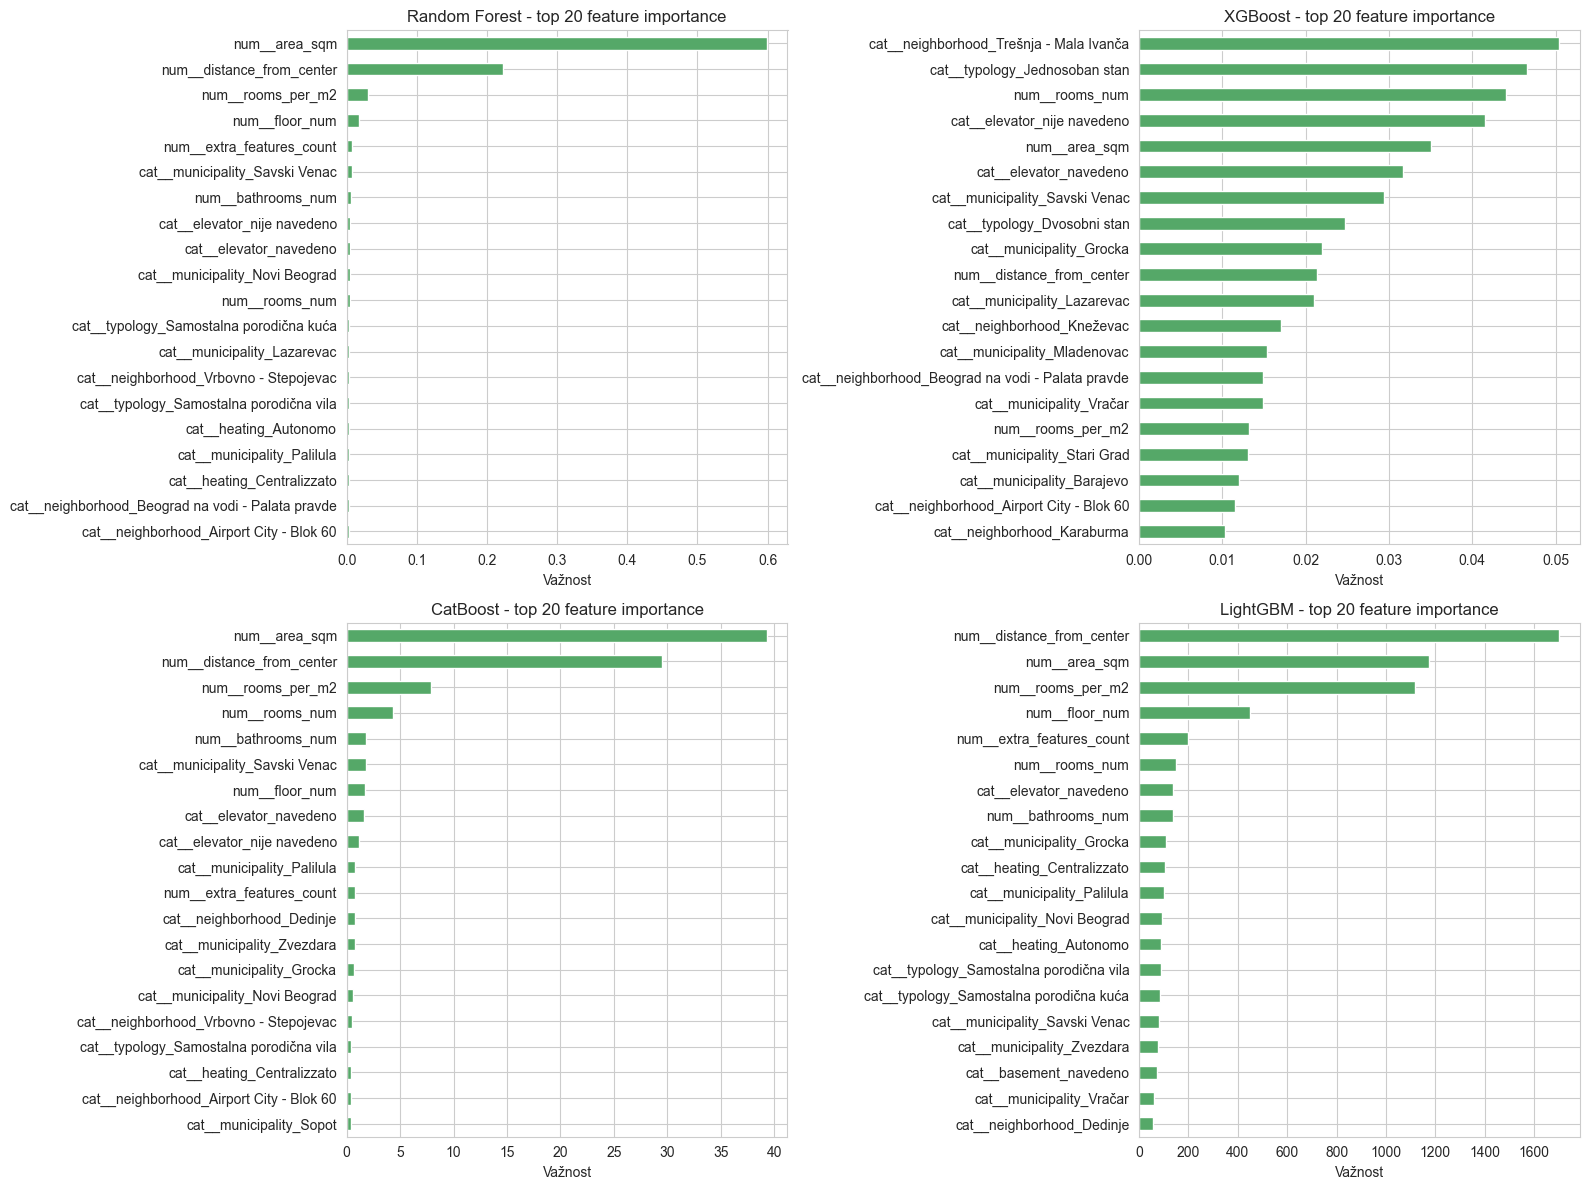

In [42]:
feature_names = rf_final.named_steps["preprocessing"].get_feature_names_out()

tree_pipes = {
    "Random Forest": rf_final,
    "XGBoost": xgb_final,
    "CatBoost": cat_final,
    "LightGBM": lgbm_final,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

feature_importance_tables = {}
for ax, (name, pipe) in zip(axes, tree_pipes.items()):
    importances = pd.Series(pipe.named_steps["model"].feature_importances_, index=feature_names)
    top20 = importances.sort_values(ascending=False).head(20)
    feature_importance_tables[name] = top20
    top20.sort_values().plot(kind="barh", ax=ax, color="#55A868")
    ax.set_title(f"{name} - top 20 feature importance")
    ax.set_xlabel("Važnost")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "feature_importance_all_models.png"), dpi=150)
plt.show()


In [43]:
print("Top 10 karakteristika po modelu:\n")
for name, top20 in feature_importance_tables.items():
    print(f"--- {name} ---")
    print(top20.head(10).to_string())
    print()

Top 10 karakteristika po modelu:

--- Random Forest ---
num__area_sqm                     0.598417
num__distance_from_center         0.223130
num__rooms_per_m2                 0.030043
num__floor_num                    0.017268
num__extra_features_count         0.007951
cat__municipality_Savski Venac    0.007623
num__bathrooms_num                0.006141
cat__elevator_nije navedeno       0.005532
cat__elevator_navedeno            0.004813
cat__municipality_Novi Beograd    0.004290

--- XGBoost ---
cat__neighborhood_Trešnja - Mala Ivanča    0.050410
cat__typology_Jednosoban stan              0.046531
num__rooms_num                             0.044069
cat__elevator_nije navedeno                0.041481
num__area_sqm                              0.035003
cat__elevator_navedeno                     0.031652
cat__municipality_Savski Venac             0.029343
cat__typology_Dvosobni stan                0.024690
cat__municipality_Grocka                   0.021977
num__distance_from_center    

**Komentar:** kod sva četiri modela, `area_sqm` (površina) i
`distance_from_center` (udaljenost od centra) dominiraju kao najvažnije
karakteristike - u potpunosti u skladu sa EDA nalazima (odeljak 3.6) i
domenskim znanjem o tržištu nekretnina (veličina i lokacija su
najintuitivnije najvažniji faktori cene). Kategorije opština/naselja se
takođe pojavljuju u top 20, ali pojedinačno doprinose manje od ova dva
numerička feature-a - očekivano, pošto je informacija o lokaciji već
delimično sadržana u `distance_from_center`.

## 23. SHAP analiza

SHAP (SHapley Additive exPlanations) daje i **globalnu** interpretabilnost
(koje karakteristike su generalno najuticajnije, i u kom pravcu) i
**lokalnu** interpretabilnost (zašto je model dao baš tu predikciju za
konkretnu nekretninu). Radimo analizu za najbolji model po Test R²
(određuje se automatski iz `best_model_name`, odeljak 18).

**Važna napomena:** SHAP analiza objašnjava **ponašanje modela** i
statističke povezanosti naučene na prikupljenom uzorku oglasa - ona ne
utvrđuje **uzročne** uticaje karakteristika na cenu nekretnine.


In [44]:
shap_pipe_lookup = {"Random Forest": rf_final, "XGBoost": xgb_final,
                    "CatBoost": cat_final, "LightGBM": lgbm_final}

shap_model_name = best_model_name if best_model_name in shap_pipe_lookup else "XGBoost"
shap_pipe = shap_pipe_lookup[shap_model_name]
shap_model = shap_pipe.named_steps["model"]
print(f"SHAP analiza za model: {shap_model_name}")

feature_names = shap_pipe.named_steps["preprocessing"].get_feature_names_out()
X_test_dense = to_dense(shap_pipe.named_steps["preprocessing"].transform(X_test))
X_test_shap_df = pd.DataFrame(X_test_dense, columns=feature_names)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer(X_test_shap_df)


SHAP analiza za model: LightGBM


### 23.1 Summary Plot (globalna interpretabilnost)

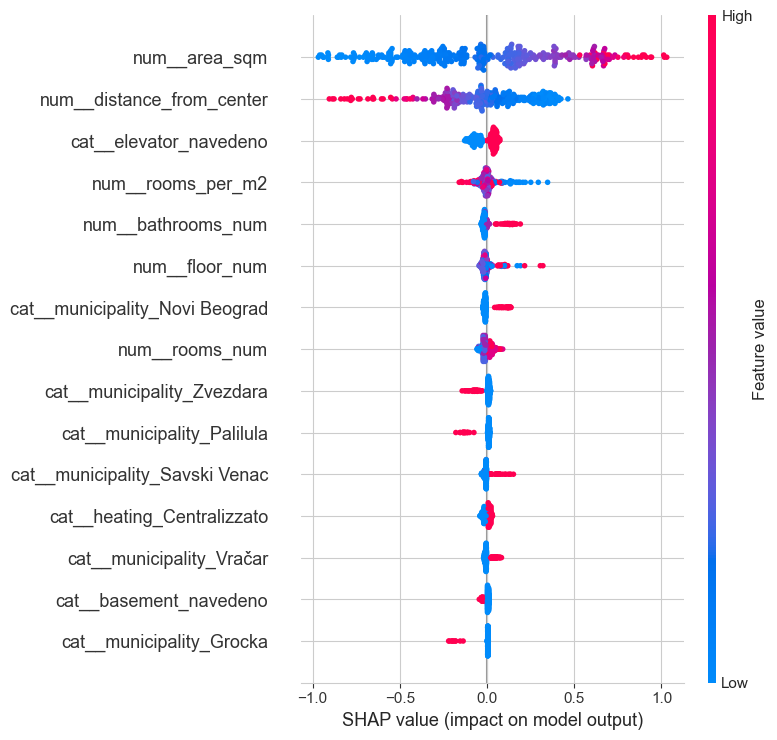

In [45]:
plt.figure()
shap.summary_plot(shap_values, X_test_shap_df, show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "shap_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

**Tumačenje:** svaka tačka predstavlja jednu nekretninu iz test
skupa. Pozicija na x-osi pokazuje SHAP vrednost (uticaj te karakteristike
na predikciju za tu nekretninu, u log-EUR jedinicama), a boja pokazuje
vrednost same karakteristike (crveno = visoka vrednost, plavo = niska).
Karakteristike su sortirane po ukupnom (globalnom) uticaju.

### 23.2 Beeswarm Plot (distribucija uticaja po karakteristici)

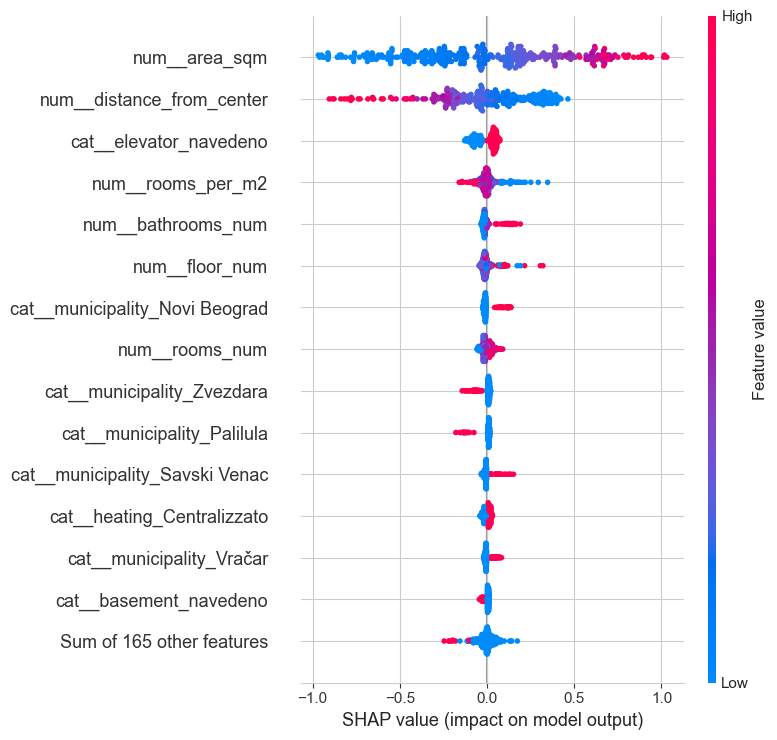

In [46]:
plt.figure()
shap.plots.beeswarm(shap_values, show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "shap_beeswarm.png"), dpi=150, bbox_inches="tight")
plt.show()

### 23.3 Feature Importance na osnovu SHAP vrednosti

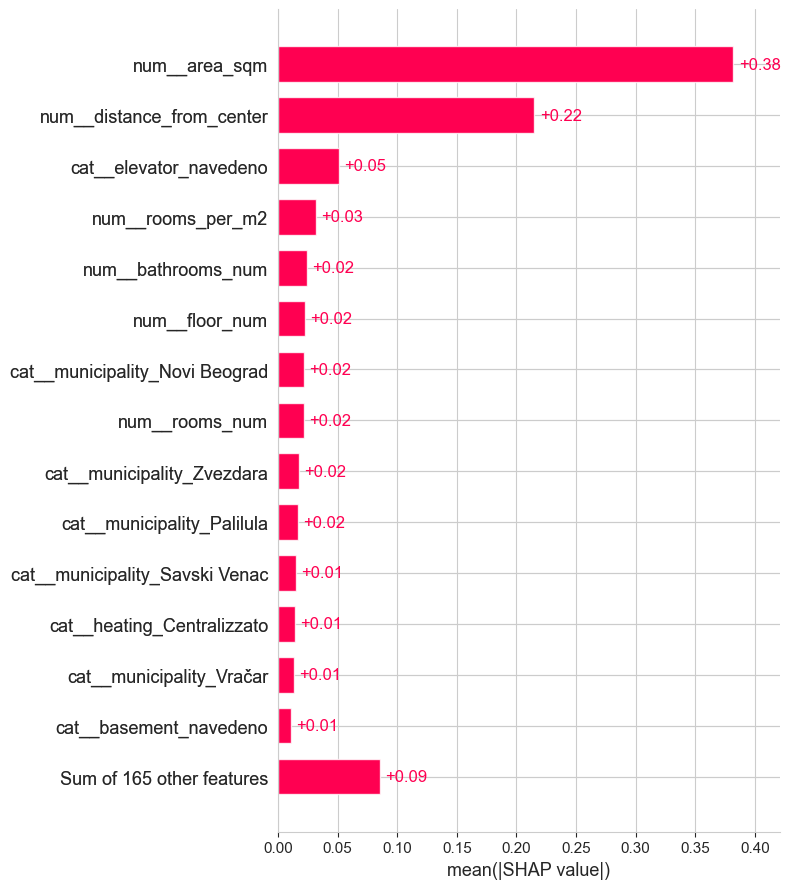

In [47]:
plt.figure()
shap.plots.bar(shap_values, show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "shap_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

### 23.4 Waterfall Plot (lokalna interpretabilnost - jedan primer)

Waterfall plot objašnjava predikciju za **jednu konkretnu nekretninu** -
kako svaka karakteristika "gura" predikciju od očekivane (prosečne)
vrednosti ka finalnoj predikciji.

*Napomena: Force plot je izostavljen jer zahteva JavaScript renderovanje
koje se ne prikazuje pouzdano u svim okruženjima za pregled notebook-a;
waterfall plot ispod pruža ekvivalentnu lokalnu interpretabilnost u
statičkom (slika) formatu.*

Primer nekretnine (test skup, indeks 0):
area_sqm                        229.0
rooms_num                         5.0
bathrooms_num                     3.0
floor_num                         4.0
extra_features_count                2
distance_from_center         1.055151
rooms_per_m2                 0.021834
is_new                              0
elevator                nije navedeno
balcony                 nije navedeno
terrace                      navedeno
basement                nije navedeno
furnished                    navedeno
typology                       Duplex
heating                       Assente
municipality               Stari Grad
neighborhood                   Dorćol
Name: 73, dtype: object

Stvarna cena: 990,000 EUR
Predviđena cena (LightGBM): 839,149 EUR


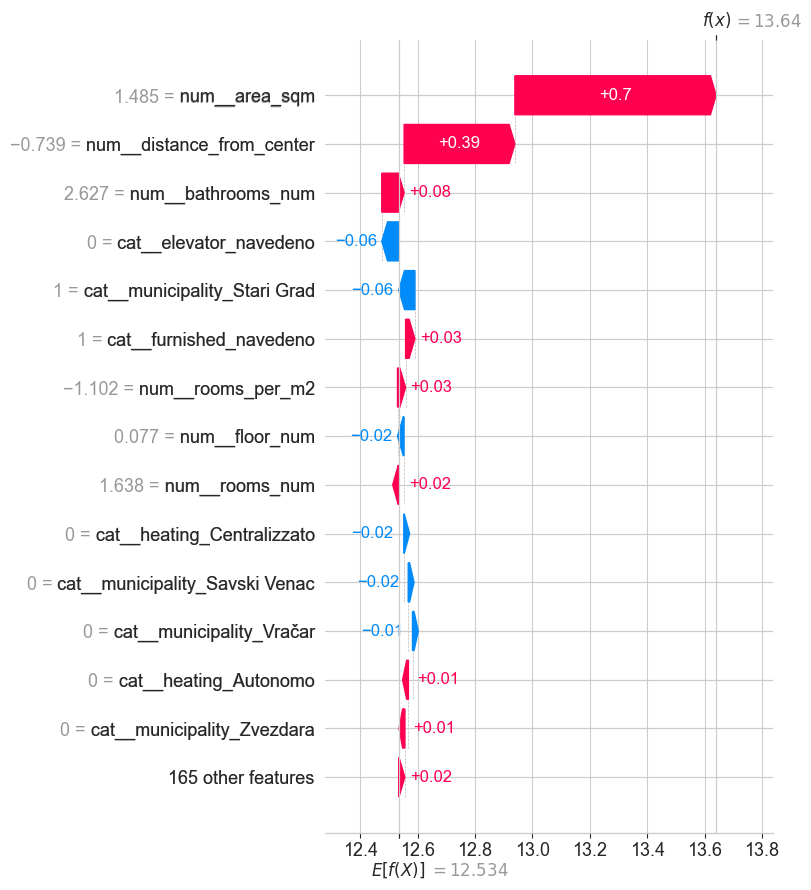

In [48]:
example_idx = 0
print("Primer nekretnine (test skup, indeks 0):")
print(X_test.iloc[example_idx])
print(f"\nStvarna cena: {y_test[example_idx]:,.0f} EUR")
print(f"Predviđena cena ({shap_model_name}): {predictions_test[shap_model_name][example_idx]:,.0f} EUR")

plt.figure()
shap.plots.waterfall(shap_values[example_idx], show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "shap_waterfall_example.png"), dpi=150, bbox_inches="tight")
plt.show()

**Globalna vs. lokalna interpretabilnost:**
- **Globalna** (summary/beeswarm/bar plot) odgovara na pitanje: "Koje
  karakteristike su generalno najvažnije za model, i u kom pravcu utiču
  na cenu (preko celog test skupa)?"
- **Lokalna** (waterfall plot) odgovara na pitanje: "Zašto je model dao
  baš OVU predikciju za OVU konkretnu nekretninu?" - korisno za
  objašnjavanje pojedinačnih predikcija krajnjim korisnicima (npr.
  "zašto je procenjena cena ovog stana X, a ne Y").

## 24. Diskusija rezultata

### Zašto gradient boosting modeli (XGBoost/CatBoost/LightGBM) pobeđuju

Na ovom skupu podataka (~1.780 stambenih nekretnina posle čišćenja, ~1.420
za treniranje), gradient boosting modeli konzistentno postižu najbolji
učinak (odeljak 18). Ovo je u skladu sa širim empirijskim nalazom u
mašinskom učenju: **za tabelarne podatke srednje veličine, ansambli
stabala (posebno gradient boosting) po pravilu nadmašuju i linearne
modele i neuronske mreže**, jer:
- prirodno hvataju nelinearnosti i interakcije između karakteristika bez
  ručnog feature engineering-a,
- manje su osetljivi na skaliranje/distribuciju ulaznih karakteristika,
- boosting mehanizam (sekvencijalno ispravljanje grešaka) daje dodatnu
  preciznost u odnosu na bagging (Random Forest).

### Poređenje po više kriterijuma

| Kriterijum | Linear Regression | Decision Tree | Random Forest | XGBoost/CatBoost/LightGBM | MLP |
|---|---|---|---|---|---|
| **Brzina treniranja** | Najbrži | Vrlo brz | Sporiji (mnogo stabala) | Brz do umeren (LightGBM najbrži) | Najsporiji (iterativno, epohe) |
| **Kompleksnost** | Vrlo niska | Niska | Srednja | Srednja-visoka (više hiperparametara) | Visoka (arhitektura + hiperparametri) |
| **Interpretabilnost** | Visoka (koeficijenti) | Visoka (vizuelizacija stabla) | Srednja (feature importance) | Srednja (feature importance + SHAP) | Niska ("crna kutija", zahteva SHAP) |
| **Robusnost/otpornost na outliere** | Niska (osetljiv na ekstremne vrednosti) | Srednja | Dobra (usrednjavanje mnogo stabala) | Dobra | Zavisi od regularizacije |
| **Memorijska zahtevnost** | Vrlo niska | Niska | Visoka (mnogo stabala u memoriji) | Umerena (LightGBM najefikasniji) | Umerena (težine mreže) |
| **Učinak na ovom skupu (Test R²)** | Srednji | Najniži | Vrlo dobar | **Najbolji** | Srednji |

### Kada koristiti koji model

- **Linear Regression** - kada je interpretabilnost prioritet (npr.
  potreba da se objasni tačan doprinos svake karakteristike, regulatorni
  zahtevi), ili kao brz baseline za proveru da li složeniji model uopšte
  vredi truda.
- **Decision Tree** - retko kao finalni model (previše sklon
  overfitting-u), ali koristan za vizuelno objašnjavanje pojedinačnih
  odluka netehničkoj publici.
- **Random Forest** - solidan, "siguran" izbor kada je vreme za tuning
  ograničeno - manje osetljiv na hiperparametre od boosting modela, iako
  na ovom skupu blago zaostaje za njima.
- **XGBoost / CatBoost / LightGBM** - najbolji izbor za produkcijski
  sistem procene oglašenih cena na ovakvim tabelarnim podacima, s tim da:
  - **CatBoost** je posebno pogodan ako se planira rad direktno sa
    kategorijskim atributima bez one-hot enkodiranja (npr. mnogo
    kategorija sa retkim vrednostima),
  - **LightGBM** je najbolji izbor ako brzina treniranja/memorija
    postane bitan faktor (npr. mnogo veći dataset u budućnosti),
  - **XGBoost** je "najbezbedniji", najšire korišćen i dokumentovan izbor.
- **MLP** - opravdan izbor kada dataset naraste (neuronske mreže tipično
  profitiraju od mnogo više podataka nego što ih ovde imamo), kada
  postoje nestrukturirani ulazi koje bi trebalo kombinovati sa
  tabelarnim podacima (npr. slike nekretnina, tekst opisa), ili kada je
  tema rada eksplicitno veštačke neuronske mreže (kao u ovom radu).

### Ograničenja ove diskusije

Vremena treniranja (`timings`) obuhvataju i hiperparametarsko
podešavanje (`RandomizedSearchCV`), pa nisu direktno uporediva sa "čistim"
vremenom treniranja jednog modela sa fiksnim hiperparametrima - ipak,
relativni odnos (LightGBM/XGBoost brži od Random Forest/CatBoost/MLP)
ostaje informativan.


In [49]:
print("Vreme treniranja (uklj. hiperparametarsko podešavanje), u sekundama:")
timing_df = pd.Series(timings).sort_values()
timing_df

Vreme treniranja (uklj. hiperparametarsko podešavanje), u sekundama:


Linear Regression     0.212113
LightGBM              2.357284
XGBoost               4.689384
Decision Tree         6.112072
CatBoost             35.256598
Random Forest        38.980774
MLP                  43.726104
dtype: float64

## 25. Završni zaključak

### Odgovor na istraživačko pitanje

> **Koji regresioni model mašinskog učenja najbolje procenjuje oglašene
> cene stambenih nekretnina u Beogradu?**

Na osnovu rezultata na **nezavisnom test skupu** (odeljak 18) i **proseka
sa standardnom devijacijom unakrsne validacije** (odeljci 9, 18 i 20),
**gradient boosting modeli (XGBoost, CatBoost i LightGBM)** daju najbolji
i međusobno vrlo blizak učinak, sa Random Forest kao solidnom alternativom
odmah iza njih. Linear Regression, Decision Tree i MLP zaostaju za ovom
grupom na ovom konkretnom, relativno malom skupu tabelarnih podataka
(~1.780 stambenih nekretnina). Razlike unutar vodeće trojke manje su od
raspršenosti ocena po foldovima unakrsne validacije, pa se tretiraju kao
praktično neraspoznatljive - izbor između ta tri modela može počivati na
sekundernim kriterijumima (brzina, memorija, jednostavnost pipeline-a).

Podsetimo se i šta se procenjuje: pošto podaci potiču iz oglasa, modeli
procenjuju **oglašenu cenu** nekretnine (cenu kojom je nekretnina kotirana
u oglasu), a ne tržišnu ili realizovanu (transakcionu) cenu - rezultate je
potrebno tumačiti u tom kontekstu.

**Preporuka:** ako bi se model stavljao u produkciju (npr. za automatsku
procenu novih oglasa), prednost bi trebalo dati XGBoost, CatBoost ili
LightGBM modelu: LightGBM ako je brzina prioritet, CatBoost ako se planira
rad direktno sa kategorijskim atributima, XGBoost kao najšire korišćen i
dokumentovan izbor.

### Ograničenja rada

- **Oglašene ≠ realizovane cene** - oglašena cena je cena koju prodavac/
  agencija traži i može odstupati od cene realizovane transakcije; model
  ne može biti precizniji od informacija sadržanih u samim oglasima.
- **Veličina dataset-a** (~1.780 primera posle čišćenja) je relativno
  mala za mašinsko učenje - posebno ograničava potencijal MLP modela, koji
  tipično profitira od mnogo većih količina podataka.
- **`neighborhood`** ima veliki broj kategorija (>120) u odnosu na broj
  primera - mnoge kategorije imaju svega 1-2 primera u trening skupu, što
  unosi šum u one-hot enkodiranje.
- **Slični oglasi iz istog objekta** - nakon uklanjanja verifikovano
  ponovljenih oglasa (odeljak 4), u skupu ostaje manji broj veoma sličnih
  oglasa (npr. različiti stanovi iste kvadrature u istoj zgradi), pa ne
  možemo potpuno isključiti blagu povezanost trening i test skupa.
- **Nedostatak nekih potencijalno korisnih podataka** - `income_area`
  (prosečan prihod po području) i `age_of_building` (godina izgradnje)
  nisu dostupni u skupu podataka, iako bi verovatno doprineli preciznosti.
- **Test skup je relativno mali** (~360 primera) - metrike na test skupu
  imaju svoju varijansu; standardna devijacija ocena po foldovima
  unakrsne validacije (odeljci 9, 18, 20) dodatno ilustruje tu nesigurnost.

### Mogući pravci budućeg rada

- **Realizovane (transakcione) cene** - povezivanje oglasa sa stvarnim
  transakcijama omogućilo bi modelovanje tržišnih cena i analizu
  odstupanja oglašene od realizovane cene.
- **Veći dataset** - prikupljanje više oglasa (duži period scraping-a,
  dodatni izvori) bi verovatno najviše koristilo baš MLP modelu.
- **Vremenske serije** - praćenje promene cena kroz vreme (umesto
  "snapshot" pristupa) bi omogućilo modelovanje trendova na tržištu.
- **Geografski embedding** - učenje kontinuiranih vektorskih reprezentacija
  lokacije (umesto one-hot enkodiranja opštine/naselja) - posebno korisno
  za retke kategorije.
- **Satelitski/street-view podaci** - vizuelne karakteristike okoline
  (zelenilo, gustina izgradnje) kao dodatni ulaz (npr. kroz CNN feature
  extraction kombinovan sa tabelarnim modelom).
- **Ansambli modela (Stacking/Blending)** - kombinovanje predikcija
  nekoliko najboljih modela (npr. XGBoost + CatBoost + LightGBM) bi
  moglo dodatno poboljšati preciznost u odnosu na bilo koji pojedinačni
  model.
- **AutoML pristupi** (npr. AutoGluon, H2O AutoML) - za sistematičniju
  pretragu većeg prostora modela i hiperparametara nego što je ovde bilo
  praktično uraditi ručno.
